## 1. Imports, Directories and Functions

In [1]:
import sys
sys.path.insert(0, '/home/emma/Dokumente/thesis')
from micom import Community
import pandas as pd
import os
from itertools import chain
from optlang.symbolics import Zero
from cobra.util.context import get_context
from micom.logger import logger
from functools import partial
from functions import *
from micom.solution import solve
from micom.util import check_modification
from micom.problems import regularize_l2_norm
from collections.abc import Sized
import numpy as np
import matplotlib.pyplot as plt
import re
import seaborn as sns


In [2]:
model_dir = "/home/emma/Dokumente/thesis/Model_generation_curation/Curated_models/final"
save_dir = "/home/emma/Dokumente/thesis/communities/simulations/pfba"

media_dir = "/home/emma/Dokumente/thesis/media_creation/created_media"
taxonomy_df = pd.read_csv("/home/emma/Dokumente/thesis/communities/SynComs_taxonomy.csv")

### Functions

In [12]:
def get_biomass_objectives_and_define_as_constraint(community):
    biomass_obj = []
    coefficients = dict()
    n_taxa = len(community.taxonomy)
    
    # get all biomass reactions
    for rec in community.reactions:
        if rec.id.startswith("Growth"):
            biomass_obj.append(rec)
            
    # coefficient scaled to abundance -> for equal abundance = 1/community_size
    for rxn in biomass_obj:
        coefficients[rxn.forward_variable] = 1/n_taxa
        coefficients[rxn.reverse_variable] = -1/n_taxa

    constraint = community.problem.Constraint(0, lb = 0, ub = None)
    community.add_cons_vars(constraint)
    community.solver.update()
    constraint.set_linear_coefficients(coefficients = coefficients)
    return constraint

In [13]:
def add_pfba_objective_totalcom(community, minimal_growth, constraint, atol=1e-4, rtol=1e-4):
    """Add pFBA objective.

    Add objective to minimize the summed flux of all reactions to the
    current objective. This one will work with any objective (even non-linear
    ones).

    See Also
    --------
    pfba

    Parameters
    ----------
    community : micom.Community
        The community to add the objective to.
    """
    constraint.lb = (1-rtol) * minimal_growth - atol
    if community.solver.objective.name == "_pfba_objective":
        raise ValueError("model already has pfba objective")
    reaction_variables = (
        (rxn.forward_variable, rxn.reverse_variable) for rxn in community.reactions
    )
    variables = chain(*reaction_variables)
    community.objective = Zero
    community.objective_direction = "min"
    community.objective.set_linear_coefficients(dict.fromkeys(variables, 1.0))
    if community.modification is None:
        community.modification = "pFBA"
    else:
        community.modification += " and pFBA :)"
    community.solver.update()

In [14]:
def run_fba(community, fractions, fluxes):
    results = []
    opt_sol = community.optimize()
    for fr in fractions:
        with community:
            minimal_growth = opt_sol.growth_rate * fr
            biomass_constraint = get_biomass_objectives_and_define_as_constraint(community)
            add_pfba_objective_totalcom(community, minimal_growth, constraint = biomass_constraint, atol=1e-6, rtol=1e-6)

            community.solver.problem.parameters.advance.set(0)
            community.solver.problem.cleanup(1e-10)

            sol_pfba2 = community.optimize(fluxes=fluxes, raise_error = False)
            results.append((fr, sol_pfba2))

            print("---------")
            print(f"Tradeoff-value: {fr}")
            if sol_pfba2 != None:
                print(f"Community {community.solver.variables.community_objective.primal}")
                print(f"pFBA solution: {sol_pfba2.objective_value}")
            else:
                print(f"Solver status: {sol_pfba2}")
            print("---------")

    results_df = pd.DataFrame.from_records(results, columns=["tradeoff", "solution"])
    return results_df

In [15]:
def fix_individual_growth_rates(community, growth_rates, atol=1e-6, rtol=1e-6):
    """
    Add one constraint per taxon, fixing its individual biomass (Growth) flux
    close to the value found in `growth_rates` (e.g. from an L2 solution).

    growth_rates : dict {taxon_id: growth_rate}
    Mirrors the same lb/ub bounding pattern used in add_pfba_objective_totalcom.
    """
    constraints = []
    for rxn in community.reactions:
        if not rxn.id.startswith("Growth"):
            continue

        # MICOM tags each per-taxon reaction with the owning taxon id;
        # fall back to string-splitting the reaction id if that's unavailable
        taxon = getattr(rxn, "community_id", None)
        if taxon is None:
            # e.g. "Growth__<taxon>" or "Growth_<taxon>"
            taxon = rxn.id.split("Growth", 1)[1].lstrip("_")

        if taxon not in growth_rates:
            continue

        g = growth_rates[taxon]
        if pd.isna(g):
            continue

        lb = (1 - rtol) * g - atol
        ub = (1 + rtol) * g + atol
        # keep lb <= ub even if g is ~0 or slightly negative due to solver noise
        lb, ub = min(lb, ub), max(lb, ub)

        constraint = community.problem.Constraint(
            rxn.forward_variable - rxn.reverse_variable,
            lb=lb,
            ub=ub,
            name=f"fix_growth_{taxon}",
        )
        community.add_cons_vars(constraint)
        constraints.append(constraint)

    community.solver.update()
    return constraints

In [16]:
def run_l2_then_pfba(community, fractions, fluxes=True, atol=1e-4, rtol=1e-4):
    """
    For each tradeoff fraction:
      1. Fix community-level (weighted) growth at `fraction * max_growth`.
      2. Solve with an L2 objective on individual growth rates -> picks the
         "fair"/non-degenerate distribution of growth across taxa.
      3. Fix each taxon's growth at the value found in step 2.
      4. Switch to a pFBA objective (minimize total flux) and re-solve
         -> resolves remaining flux-level degeneracy without disturbing
         the growth distribution chosen by L2.
    """
    results = []
    opt_sol = community.optimize()
    print("optimal solution:", opt_sol.growth_rate)
    for fr in fractions:
        with community:
            minimal_growth = opt_sol.growth_rate * fr

            # --- Stage 1: L2-regularized growth distribution ---
            regularize_l2_norm(community, 0.0)

            biomass_constraint = get_biomass_objectives_and_define_as_constraint(community)
            biomass_constraint.lb = (1 - rtol) * minimal_growth - atol
            community.solver.update()

            community.solver.problem.parameters.advance.set(0)
            community.solver.problem.cleanup(1e-10)

            sol_l2 = solve(community, fluxes=False, pfba=False, atol=atol, rtol=rtol)

            if sol_l2 is None or getattr(sol_l2, "members", None) is None:
                print(f"Tradeoff {fr}: L2 stage failed, skipping")
                results.append((fr, None))
                continue

            members = sol_l2.members
            if "growth_rate" not in members.columns:
                growth_col = [c for c in members.columns if "growth" in c.lower()]
                if not growth_col:
                    print(f"Tradeoff {fr}: no growth_rate column in L2 solution.members, skipping")
                    results.append((fr, None))
                    continue
                members = members.rename(columns={growth_col[0]: "growth_rate"})

            growth_rates = members["growth_rate"].dropna().to_dict()
            growth_rates.pop("medium", None)
            # --- Stage 2: fix individual growth rates, then switch to pFBA ---
            fix_individual_growth_rates(community, growth_rates, atol=atol, rtol=rtol)

            add_pfba_objective_totalcom(
                community, minimal_growth, constraint=biomass_constraint, atol=atol, rtol=rtol
            )

            community.solver.problem.parameters.advance.set(0)
            #community.solver.problem.cleanup(1e-10)

            sol_pfba = community.optimize(fluxes=fluxes, raise_error=False)
            results.append((fr, sol_pfba))

            print("---------")
            print(f"Tradeoff-value: {fr}")
            if sol_pfba is not None:
                print(f"Community objective: {community.solver.variables.community_objective.primal}")
                print(f"pFBA solution (total flux): {sol_pfba.objective_value}")
            else:
                print(f"Solver status: {sol_pfba}")
                print(community.solver.status)
            print("---------")

    results_df = pd.DataFrame.from_records(results, columns=["tradeoff", "solution"])
    return results_df

In [17]:
def save_tradeoff_results(results_df, save_dir, prefix):
    """Saves community growth rates, individual taxon growth rates, and flux tables

    from tradeoff results to CSV files in `save_dir`.
    """
    save_path = save_dir

    summary_records = []
    taxon_growth_list = []

    for _, row in results_df.iterrows():
        tradeoff = row["tradeoff"]
        solution = row["solution"]

        # Skip failed/empty solutions
        if solution is None:
            continue

        # 1. Capture community growth rate & objective
        com_growth = getattr(solution, "growth_rate", None)
        obj_val = getattr(solution, "objective_value", None)

        summary_records.append(
            {
                "tradeoff": tradeoff,
                "community_growth": com_growth,
                "objective_value": obj_val,
                "status": getattr(solution, "status", "unknown"),
            }
        )

        # 2. Capture individual taxon growth rates (from solution.members)
        if hasattr(solution, "members") and solution.members is not None:
            members_df = solution.members.copy()
            if isinstance(members_df, pd.DataFrame):
                members_df["tradeoff"] = tradeoff
                taxon_growth_list.append(members_df)
                tradeoff_str = f"{int(tradeoff * 10):02d}"
                members_df.to_csv(os.path.join(save_path, f"{prefix}_{tradeoff_str}_individualtaxon_growth.csv"))


        # 3. Capture reaction flux matrix (from solution.fluxes)
        if hasattr(solution, "fluxes") and solution.fluxes is not None:
            fluxes_df = solution.fluxes.copy()
            if isinstance(fluxes_df, pd.DataFrame):
                fluxes_df["tradeoff"] = tradeoff
                tradeoff_str = f"{int(tradeoff * 10):02d}"
                fluxes_df.to_csv(os.path.join(save_path, f"{prefix}_{tradeoff_str}_fluxes.csv"))

    # --- Save Summary Table ---
    if summary_records:
        summary_df = pd.DataFrame(summary_records)
        summary_df.to_csv(os.path.join(save_path, f"{prefix}_community_growth_summary.csv"), index=False)

    # --- Save Taxon Growth Rates ---
    if taxon_growth_list:
        all_taxon_growth = pd.concat(taxon_growth_list, ignore_index=False)
        all_taxon_growth

    print(f"Results successfully saved to: {save_path}")

In [15]:
def compare_growth_methods(
    com_name: str,
    save_dir: str,
    methods: list[str] = None,
    normalize_by_taxa: bool = True,
):
    # -------------------------------------------------------------------------
    # 1. Compare Community Growth (Overall)
    # -------------------------------------------------------------------------
    summary_files = [
        f
        for f in os.listdir(save_dir)
        if f.startswith(com_name) and f.endswith("_community_growth_summary.csv")
    ]

    summary_dfs = []
    for file in summary_files:
        # Extract method name dynamically from filename structure
        method = file[len(com_name) + 1 : -len("_community_growth_summary.csv")]

        if methods and method not in methods:
            continue

        path = os.path.join(save_dir, file)
        df = pd.read_csv(path)

        if {"tradeoff", "community_growth"}.issubset(df.columns):
            df["method"] = method
            summary_dfs.append(df)

    if not summary_dfs:
        raise FileNotFoundError(
            f"No valid community summary files found for '{com_name}' in {save_dir}"
        )

    summary_df = pd.concat(summary_dfs, ignore_index=True)
    summary_df = summary_df.sort_values(["tradeoff", "method"]).reset_index(
        drop=True
    )
    # -------------------------------------------------------------------------
    # 2. Compare Individual Taxon Growth
    # -------------------------------------------------------------------------
    individual_files = [
        f
        for f in os.listdir(save_dir)
        if f.startswith(com_name) and f.endswith("_individualtaxon_growth.csv")
    ]

    # Flexible regex matching any method name string and 2-digit tradeoff integer
    method_pattern = (
        r"(?P<method>" + "|".join(map(re.escape, methods)) + r")"
        if methods
        else r"(?P<method>.+?)"
    )
    pattern = re.compile(
        rf"^{re.escape(com_name)}_{method_pattern}_(?P<tradeoff>\d{{2}})_individualtaxon_growth\.csv$"
    )

    taxon_growth_dfs = []
    for file in individual_files:
        match = pattern.match(file)
        if not match:
            continue

        method = match.group("method")
        tradeoff = int(match.group("tradeoff")) / 10.0
        path = os.path.join(save_dir, file)

        df = pd.read_csv(path, index_col=0)
        df.index.name = "taxon"
        df = df.reset_index()

        if df.empty:
            continue

        # Flexible column resolution for growth rate
        if "growth_rate" not in df.columns:
            growth_candidates = [c for c in df.columns if "growth" in c.lower()]
            if not growth_candidates:
                raise ValueError(f"No growth-rate column found in {path}")
            df.rename(
                columns={growth_candidates[0]: "growth_rate"}, inplace=True
            )

        df["method"] = method
        df["tradeoff"] = tradeoff
        taxon_growth_dfs.append(df)

    if not taxon_growth_dfs:
        raise FileNotFoundError(
            f"No individual taxon growth files found matching criteria for '{com_name}'."
        )

    taxon_growth_df = pd.concat(taxon_growth_dfs, ignore_index=True)
    taxon_growth_df = taxon_growth_df[
        ["taxon", "growth_rate", "tradeoff", "method"]
    ].dropna(subset=["taxon", "growth_rate"])

    # Optional scaling factor per taxon count
    if normalize_by_taxa:
        num_taxa = taxon_growth_df["taxon"].nunique()
        taxon_growth_df["growth_rate"] = taxon_growth_df["growth_rate"] * (
            1 / num_taxa
        )

    # Dynamic color palette matching the number of unique methods present
    unique_methods = taxon_growth_df["method"].unique()
    palette = dict(
        zip(unique_methods, sns.color_palette("tab10", len(unique_methods)))
    )

    # Ensure bars for each taxon are grouped side-by-side for each tradeoff
    taxa_method_order = ["L2pFBA", "pFBA"]
    method_label_map = {
        "l2pfba": "L2pFBA",
        "pfba": "pFBA",
    }

    taxon_growth_df = taxon_growth_df.copy()
    taxon_growth_df["method_label"] = taxon_growth_df["method"].str.lower().map(
        lambda m: method_label_map.get(m, m)
    )

    unique_methods = [m for m in taxa_method_order if m in taxon_growth_df["method_label"].unique()]
    if not unique_methods:
        unique_methods = list(taxon_growth_df["method_label"].unique())
    palette = dict(zip(unique_methods, sns.color_palette("tab10", len(unique_methods))))

    for tr, grp in taxon_growth_df.groupby("tradeoff"):
        grp = grp.copy()
        grp["method_label"] = grp["method"].str.lower().map(
            lambda m: method_label_map.get(m, m)
        )

        plt.figure(figsize=(12, 5))
        ax = sns.barplot(
            data=grp,
            x="taxon",
            y="growth_rate",
            hue="method_label",
            order=sorted(grp["taxon"].unique()),
            hue_order=[m for m in taxa_method_order if m in grp["method_label"].unique()],
            palette=palette,
            dodge=True,
            errorbar=None,
        )
        ax.set_xlabel("Taxon")
        ax.set_ylabel(
            "Normalised growth rate $µ_i$ [1/h]"
            if normalize_by_taxa
            else "Growth Rate"
        )
        ax.set_title(
            f"{com_name}: Individual Taxon Growth Across Methods (Tradeoff = {tr})"
        )
        ax.legend(title="Methods")
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()
    return summary_df, taxon_growth_df

## 2. Create Syncoms
- also add proper medium

In [10]:
HvSC1_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC1") | (taxonomy_df["Syncom"] == "Both")]
HvSC1_df = HvSC1_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC1_df["id"] = HvSC1_df["id"].astype(str)
HvSC1_df["abundance"] = 1
HvSC1_df["file"] = HvSC1_df['id'].apply(lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

In [11]:
HvSC2_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC2") | (taxonomy_df["Syncom"] == "Both")]
HvSC2_df = HvSC2_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC2_df["id"] = HvSC2_df["id"].astype(str)
HvSC2_df["abundance"] = 1
HvSC2_df["file"] = HvSC2_df['id'].apply(lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

In [29]:
HvSC2_892_df = taxonomy_df[(taxonomy_df["Syncom"] == "HvSC2") | (taxonomy_df["Syncom"] == "Both") | (taxonomy_df["Strain ID"] == 892)]
HvSC2_892_df = HvSC2_892_df[["Strain ID","Family"]].rename(columns={'Strain ID': 'id', 'Family': 'family'}).copy()
HvSC2_892_df["id"] = HvSC2_892_df["id"].astype(str)
HvSC2_892_df["abundance"] = 1
HvSC2_892_df["file"] = HvSC2_892_df['id'].apply(lambda x: f"{model_dir}/{x}_or_mb1_mdr_rdr_dp_mb2_lib_bz_fix.xml")

In [12]:
HvSC1 = Community(HvSC1_df, id = "HvSC1", name = "HvSC1")

Output()

In [13]:
HvSC2 = Community(HvSC2_df, id = "HvSC2", name = "HvSC2")

Output()

In [30]:
# building on dropout results: dropin 892 to SC2 to see if this saves it :) 
HvSC2_892 = Community(HvSC2_892_df, id = "HvSC2_892", name = "HvSC2_892")

Output()

In [7]:
af_path = os.path.join(media_dir, "af_diff_growth/combined_af7_c1i127.csv")
af_complete = pd.read_csv(af_path, names = ["reaction", "flux"])

In [8]:
af_complete = create_medium(af_complete)

In [16]:
HvSC1.medium = af_complete

In [17]:
HvSC2.medium = af_complete

In [31]:
HvSC2_892.medium = af_complete

## 3. Run pFBA

In [41]:
fractions = [x / 10.0 for x in range(0, 11, 1)]

In [10]:
fractions = [0.5, 1]

In [105]:
results_sc1 = run_fba(HvSC1, fractions=fractions, fluxes=True)

---------
Tradeoff-value: 0.5
Community 3.767630294689394
pFBA solution: 51295.73786629083
---------
---------
Tradeoff-value: 1
Community 7.535261593087029
pFBA solution: 161295.1599124861
---------


In [106]:
results_sc2 = run_fba(HvSC2, fractions=fractions, fluxes=True)

---------
Tradeoff-value: 0.5
Community 2.9733200078636193
pFBA solution: 39444.52152745158
---------
---------
Tradeoff-value: 1
Community 5.946641149448173
pFBA solution: 183686.40293077665
---------


In [107]:
save_tradeoff_results(results_sc1, "/home/emma/Dokumente/thesis/communities/simulations/pfba",prefix="HvSC1_pfba_x")

Results successfully saved to: /home/emma/Dokumente/thesis/communities/simulations/pfba


In [108]:
save_tradeoff_results(results_sc2, "/home/emma/Dokumente/thesis/communities/simulations/pfba",prefix="HvSC2_pfba_x")

Results successfully saved to: /home/emma/Dokumente/thesis/communities/simulations/pfba


## 4. compare to L2 norm results

In [24]:
def cooperative_tradeoff_custom(community, objective_growth, fraction, fluxes, rtol, atol):
    """Find the best tradeoff between community and individual growth."""
    check_modification(community)
    if not isinstance(fraction, Sized):
        fraction = [fraction]
    else:
        fraction = np.sort(fraction)[::-1]

    results = []
    for fr in fraction:
        with community as com:
            regularize_l2_norm(com, 0.0)

            minimal_growth = objective_growth * fr
            biomass_constraint = get_biomass_objectives_and_define_as_constraint(com)
            biomass_constraint.lb = (1 - rtol) * minimal_growth - atol
            com.solver.update()

            com.solver.problem.parameters.advance.set(0)
            com.solver.problem.cleanup(1e-10)

            sol = solve(com, fluxes=fluxes, pfba=False, atol=1e-4, rtol=1e-4)
            results.append((fr, sol))

    return pd.DataFrame.from_records(results, columns=["tradeoff", "solution"])

### 4.1 compute L2 results 

In [19]:
opt_Sc2 = HvSC2.optimize()

In [20]:
opt_Sc1 = HvSC1.optimize()

In [25]:
cooperative_tradeoff_c1 = cooperative_tradeoff_custom(HvSC1, opt_Sc1.growth_rate, fraction=fractions, fluxes = True, atol = 1e-4, rtol=1e-4)

In [26]:
cooperative_tradeoff_c2 = cooperative_tradeoff_custom(HvSC2, opt_Sc2.growth_rate, fraction=fractions, fluxes = True, atol = 1e-4, rtol=1e-4)

In [29]:
c = cooperative_tradeoff_c1.iloc[0]["solution"].fluxes

In [34]:
p = pd.read_csv("/home/emma/Dokumente/thesis/communities/simulations/pfba/HvSC1_l2pfba_10_fluxes.csv")

In [35]:
p = p.loc[:, p.columns.str.startswith("EX_")]

In [ ]:
c = c.loc[:, c.columns.str.startswith("EX_")]

In [74]:
save_tradeoff_results(cooperative_tradeoff_c1,"/home/emma/Dokumente/thesis/communities/simulations/pfba", "HvSC1_L2" )

Results successfully saved to: /home/emma/Dokumente/thesis/communities/simulations/pfba


In [71]:
save_tradeoff_results(cooperative_tradeoff_c2,"/home/emma/Dokumente/thesis/communities/simulations/pfba", "HvSC2_L2" )

Results successfully saved to: /home/emma/Dokumente/thesis/communities/simulations/pfba


### 4.2 comparison in growth rates between L2 and pfba

In [19]:
def compare_growth_methods(
    com_name: str,
    save_dir: str,
    methods: list[str] = None,
    normalize_by_taxa: bool = True,
):
    # -------------------------------------------------------------------------
    # 1. Compare Community Growth (Overall)
    # -------------------------------------------------------------------------
    summary_files = [
        f
        for f in os.listdir(save_dir)
        if f.startswith(com_name) and f.endswith("_community_growth_summary.csv")
    ]

    summary_dfs = []
    for file in summary_files:
        method = file[len(com_name) + 1 : -len("_community_growth_summary.csv")]

        if methods and method not in methods:
            continue

        path = os.path.join(save_dir, file)
        df = pd.read_csv(path)

        if {"tradeoff", "community_growth"}.issubset(df.columns):
            df["method"] = method
            summary_dfs.append(df)

    if not summary_dfs:
        raise FileNotFoundError(
            f"No valid community summary files found for '{com_name}' in {save_dir}"
        )

    summary_df = pd.concat(summary_dfs, ignore_index=True)
    summary_df = summary_df.sort_values(["tradeoff", "method"]).reset_index(drop=True)

    # -------------------------------------------------------------------------
    # 2. Compare Individual Taxon Growth
    # -------------------------------------------------------------------------
    individual_files = [
        f
        for f in os.listdir(save_dir)
        if f.startswith(com_name) and f.endswith("_individualtaxon_growth.csv")
    ]

    method_pattern = (
        r"(?P<method>" + "|".join(map(re.escape, methods)) + r")"
        if methods
        else r"(?P<method>.+?)"
    )
    pattern = re.compile(
        rf"^{re.escape(com_name)}_{method_pattern}_(?P<tradeoff>\d{{2}})_individualtaxon_growth\.csv$"
    )

    taxon_growth_dfs = []
    for file in individual_files:
        match = pattern.match(file)
        if not match:
            continue

        method = match.group("method")
        tradeoff = int(match.group("tradeoff")) / 10.0
        path = os.path.join(save_dir, file)

        df = pd.read_csv(path, index_col=0)
        df.index.name = "taxon"
        df = df.reset_index()

        if df.empty:
            continue

        if "growth_rate" not in df.columns:
            growth_candidates = [c for c in df.columns if "growth" in c.lower()]
            if not growth_candidates:
                raise ValueError(f"No growth-rate column found in {path}")
            df.rename(columns={growth_candidates[0]: "growth_rate"}, inplace=True)

        df["method"] = method
        df["tradeoff"] = tradeoff
        taxon_growth_dfs.append(df)

    if not taxon_growth_dfs:
        raise FileNotFoundError(
            f"No individual taxon growth files found matching criteria for '{com_name}'."
        )

    taxon_growth_df = pd.concat(taxon_growth_dfs, ignore_index=True)
    taxon_growth_df = taxon_growth_df[["taxon", "growth_rate", "tradeoff", "method"]].copy()
    taxon_growth_df = taxon_growth_df.dropna(subset=["taxon", "growth_rate"]).copy()

    # Normalize mixed taxon labels to strings and drop non-taxon rows
    taxon_growth_df["taxon"] = taxon_growth_df["taxon"].map(lambda x: str(x).strip())
    taxon_growth_df = taxon_growth_df[
        ~taxon_growth_df["taxon"].str.lower().isin(["medium", "community", "nan"])
    ].copy()

    if normalize_by_taxa:
        num_taxa = taxon_growth_df["taxon"].nunique()
        taxon_growth_df["growth_rate"] = taxon_growth_df["growth_rate"] * (1 / num_taxa)

    unique_methods = taxon_growth_df["method"].unique()
    palette = dict(zip(unique_methods, sns.color_palette("tab10", len(unique_methods))))

    taxa_method_order = ["pFBA", "L2pFBA"]
    method_label_map = {
        "l2pfba": "L2pFBA",
        "pfba": "pFBA",
    }

    taxon_growth_df = taxon_growth_df.copy()
    taxon_growth_df["method_label"] = taxon_growth_df["method"].str.lower().map(
        lambda m: method_label_map.get(m, m)
    )

    unique_methods = [m for m in taxa_method_order if m in taxon_growth_df["method_label"].unique()]
    if not unique_methods:
        unique_methods = list(taxon_growth_df["method_label"].unique())
    palette = dict(zip(unique_methods, sns.color_palette("tab10", len(unique_methods))))

    for tr, grp in taxon_growth_df.groupby("tradeoff"):
        grp = grp.copy()
        grp["taxon"] = grp["taxon"].astype(str)

        def taxon_sort_key(v):
            s = str(v)
            if s.isdigit():
                return (0, int(s))
            return (1, s)

        taxa_order = sorted(grp["taxon"].unique(), key=taxon_sort_key)

        plt.figure(figsize=(12, 5))
        ax = sns.barplot(
            data=grp,
            x="taxon",
            y="growth_rate",
            hue="method_label",
            order=taxa_order,
            hue_order=[m for m in taxa_method_order if m in grp["method_label"].unique()],
            palette=palette,
            dodge=True,
            errorbar=None,
        )
        ax.set_xlabel("Taxon")
        ax.set_ylabel(
            "Normalised growth rate $µ_i$ [1/h]"
            if normalize_by_taxa
            else "Growth Rate"
        )
        ax.set_title(
            f"{com_name}: Individual Taxon Growth Across Methods (Tradeoff = {tr})"
        )
        ax.legend(title="Methods")
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

    return summary_df, taxon_growth_df

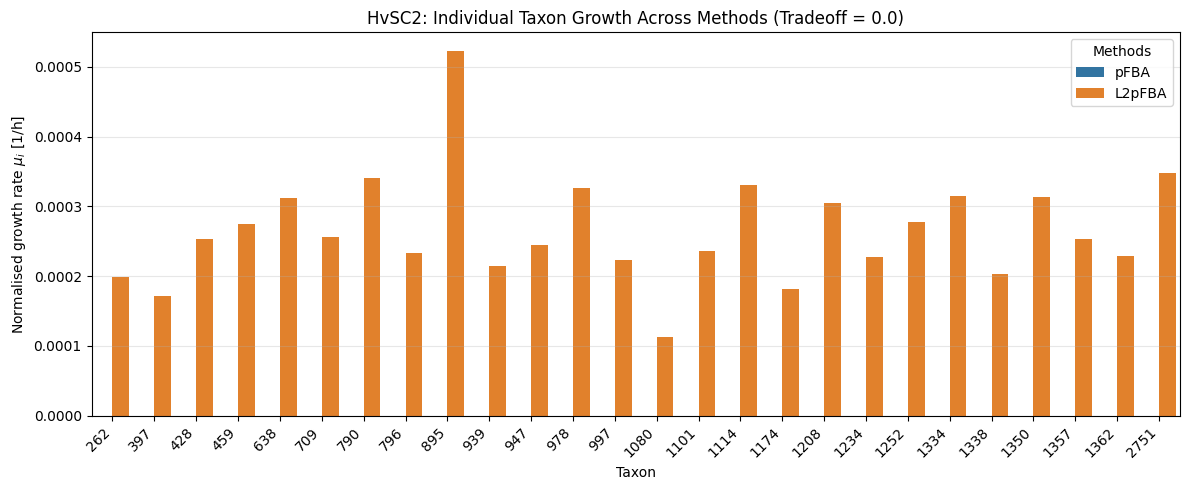

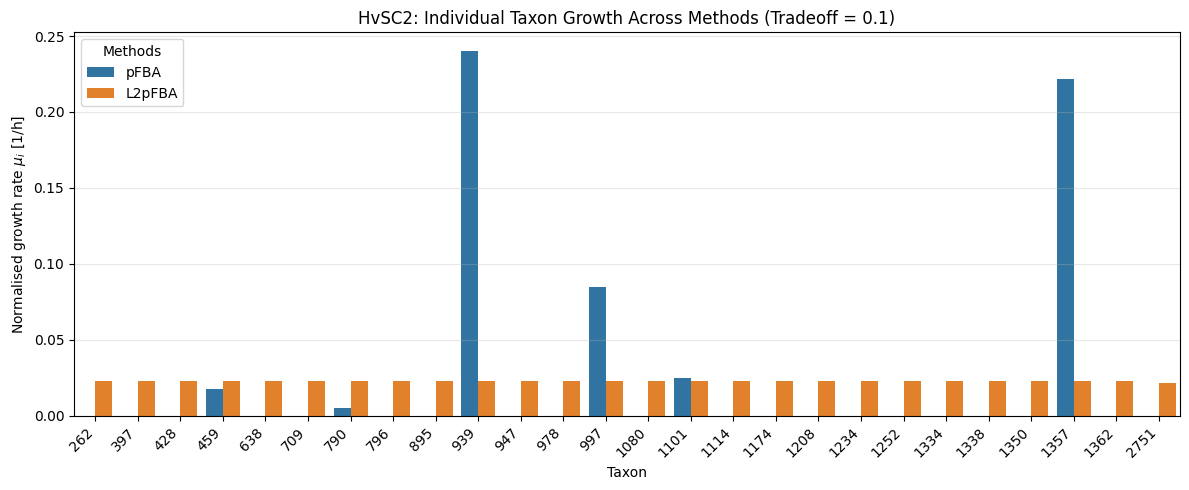

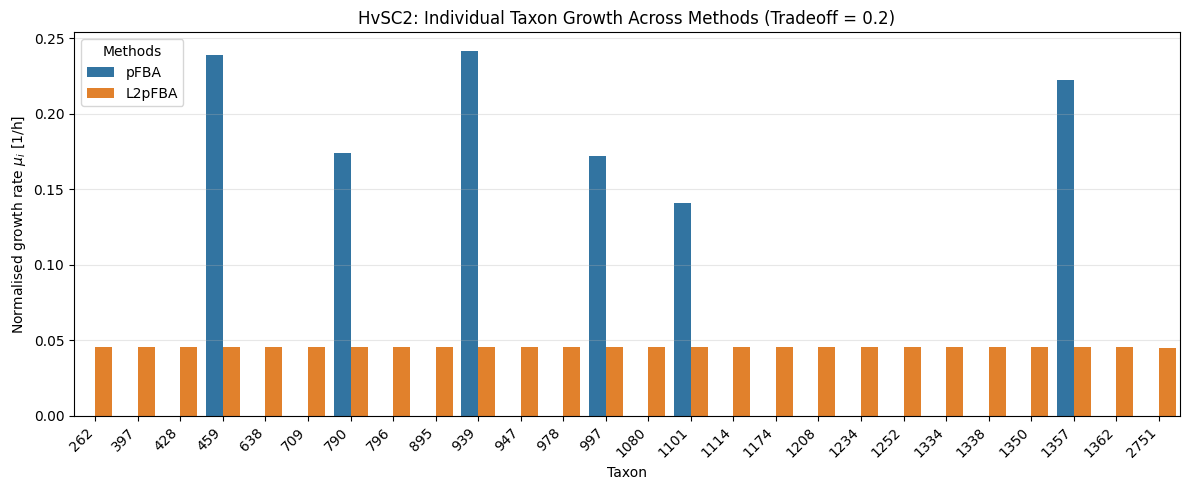

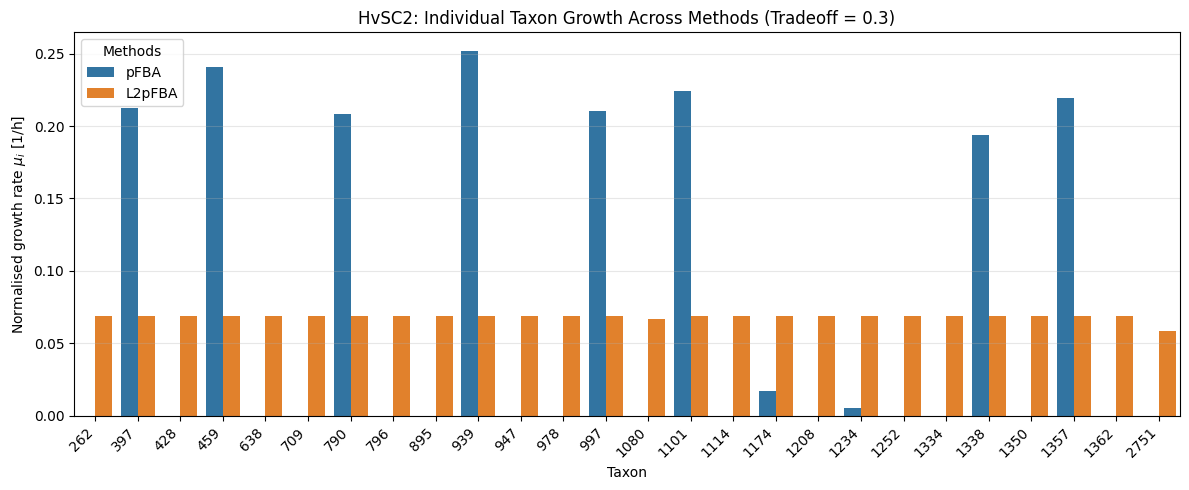

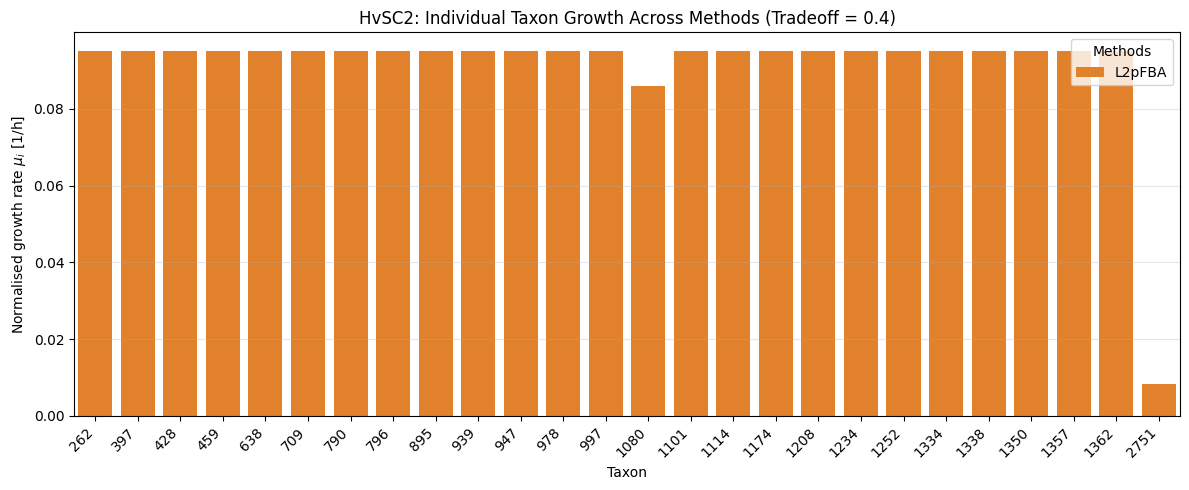

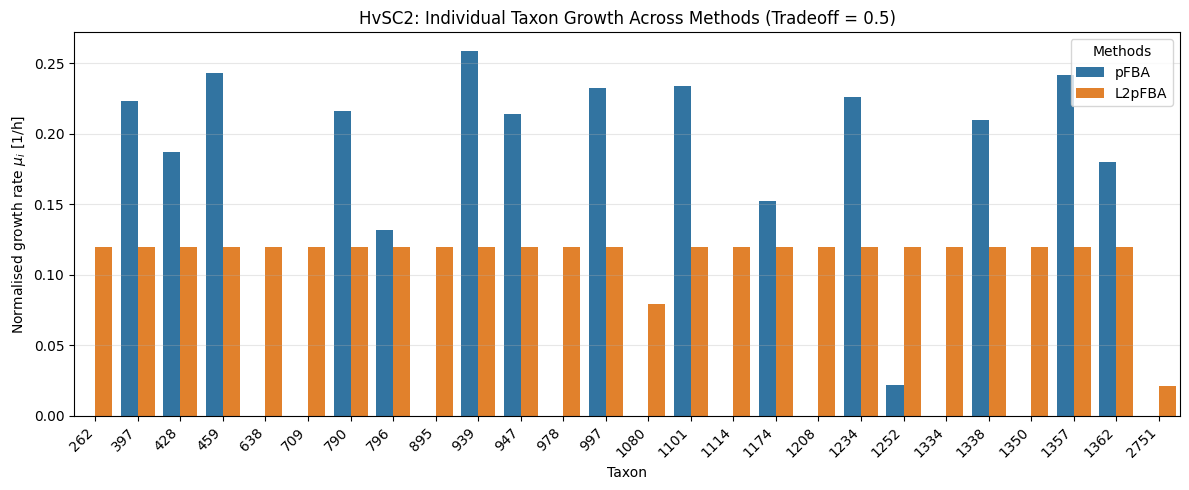

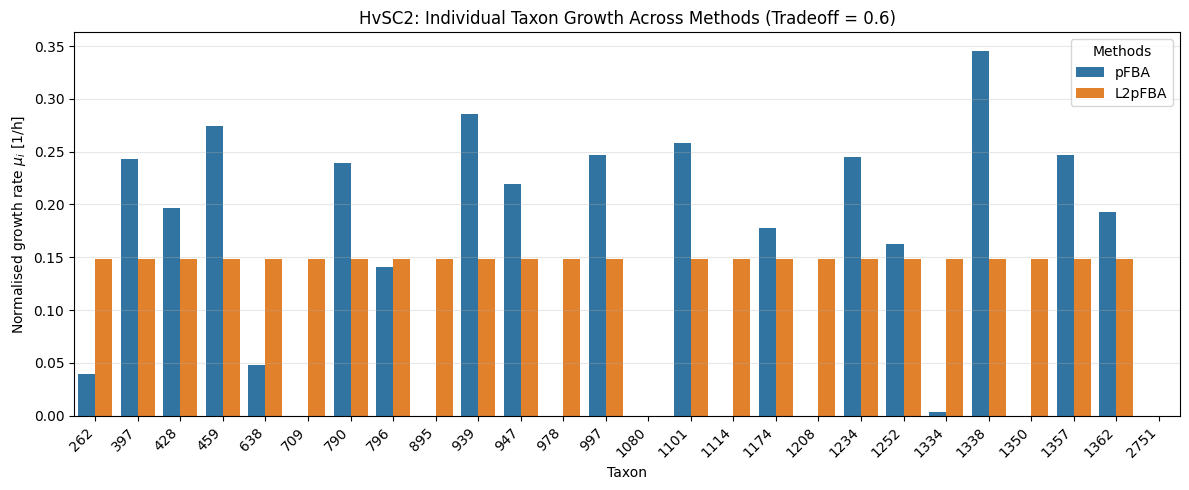

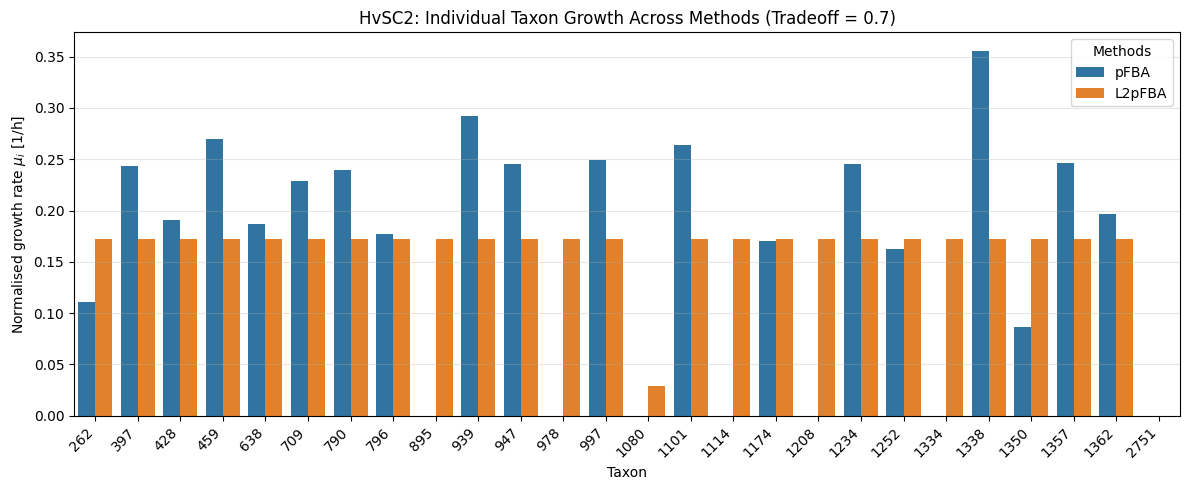

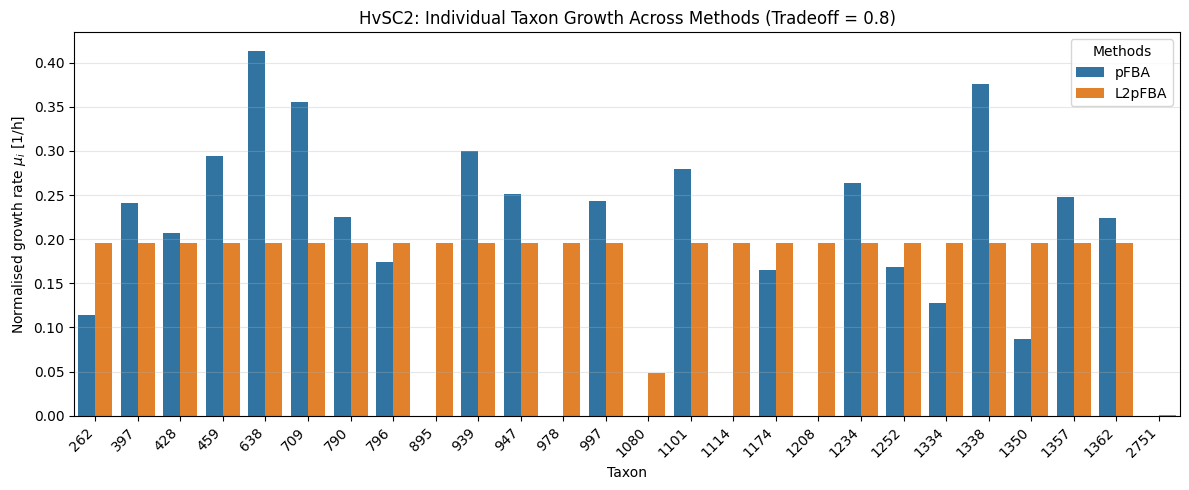

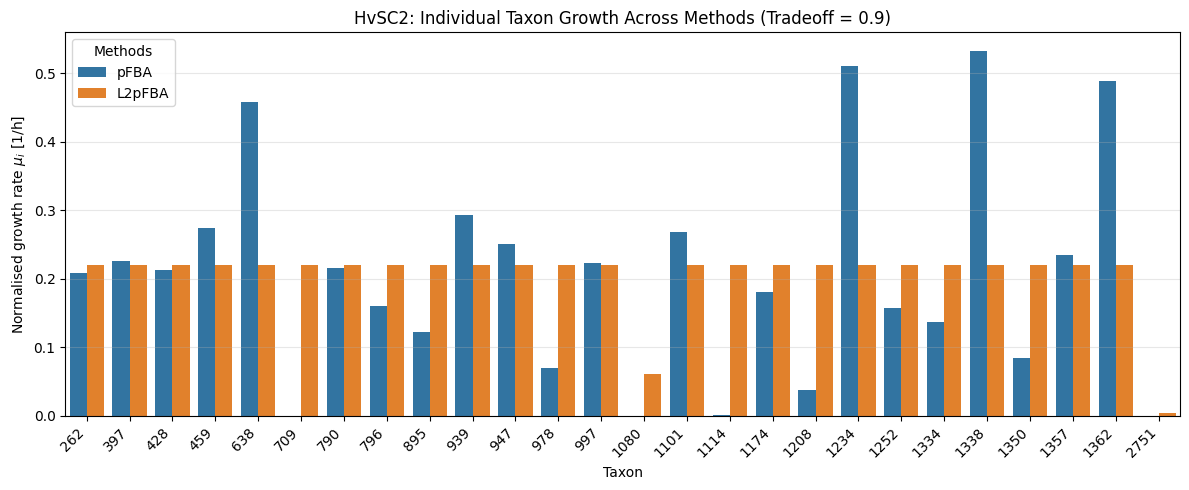

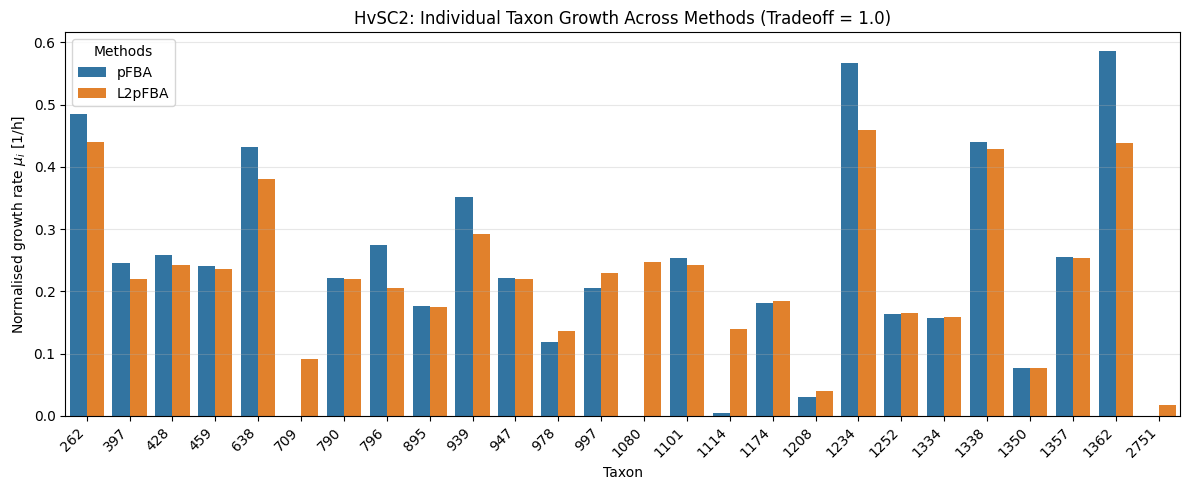

In [20]:
s2_df = compare_growth_methods("HvSC2", save_dir, ["pfba", "l2pfba"])

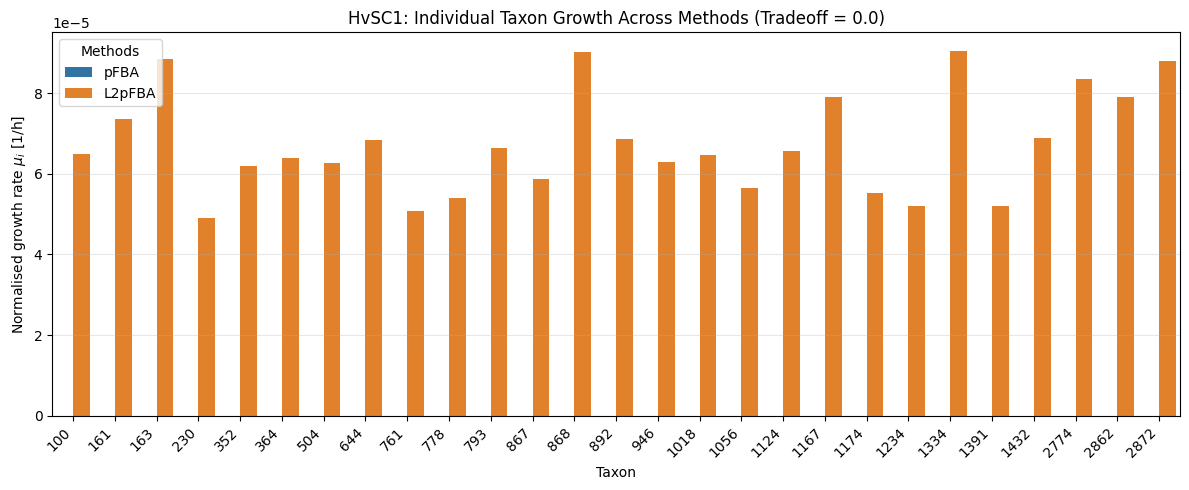

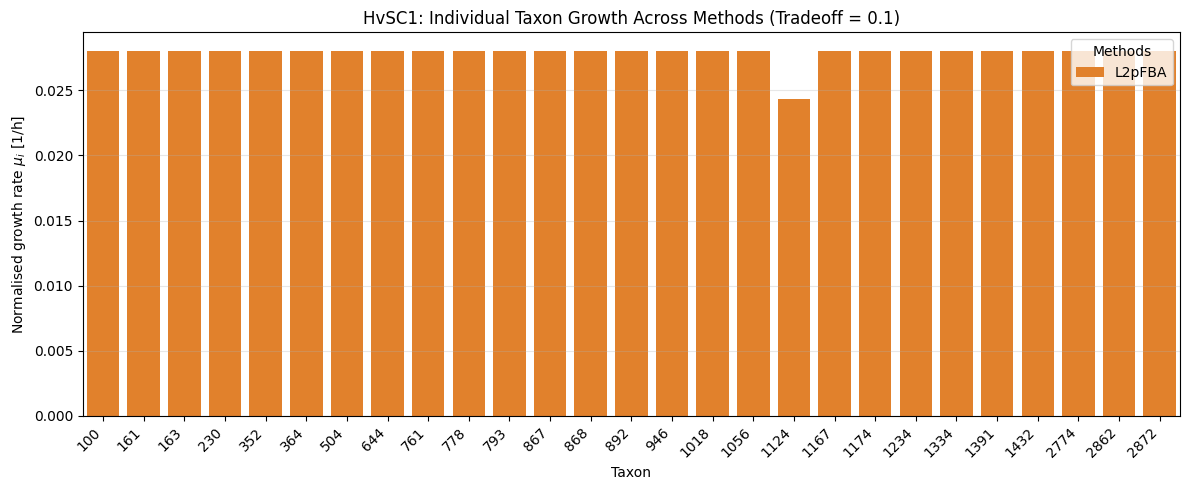

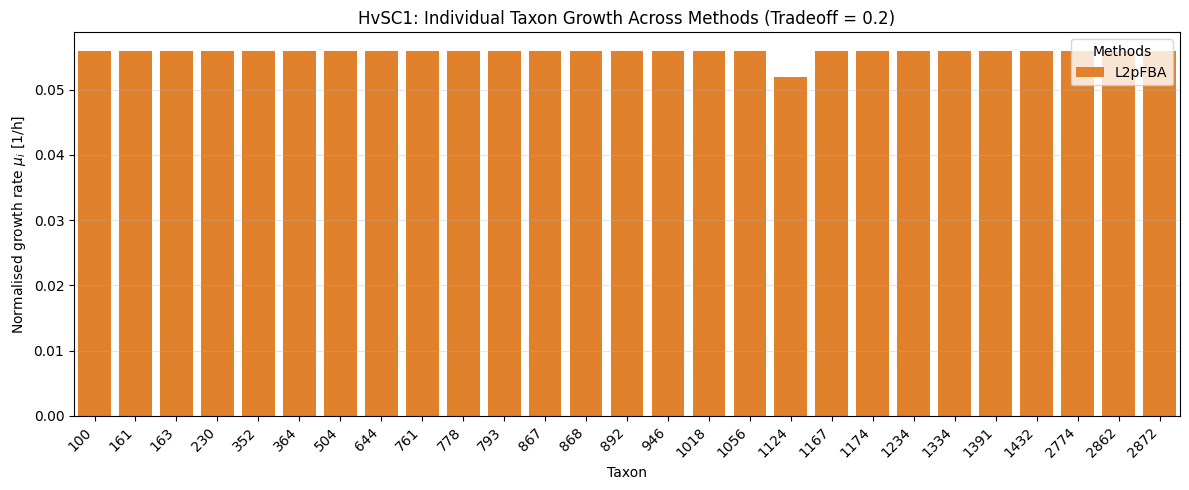

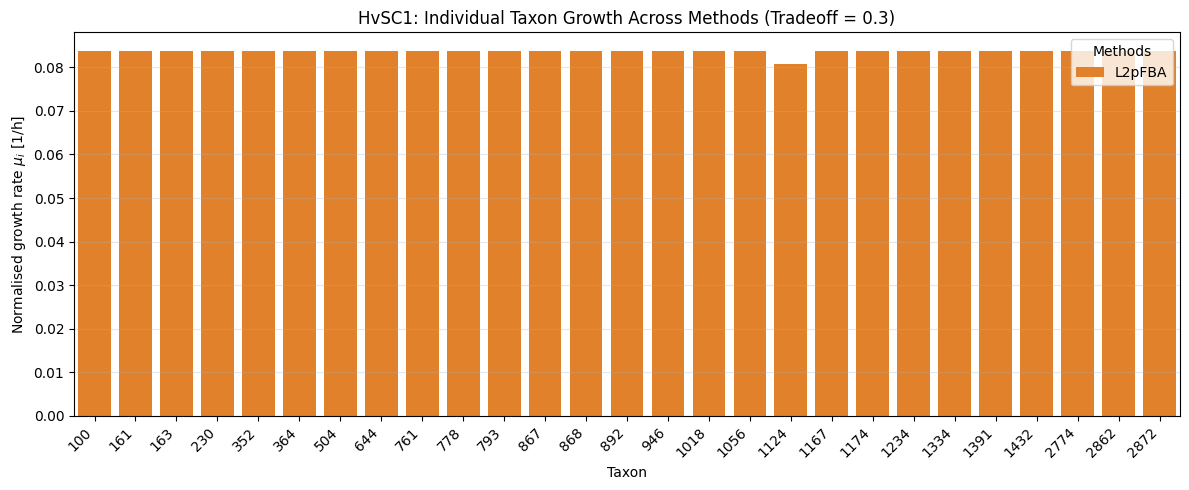

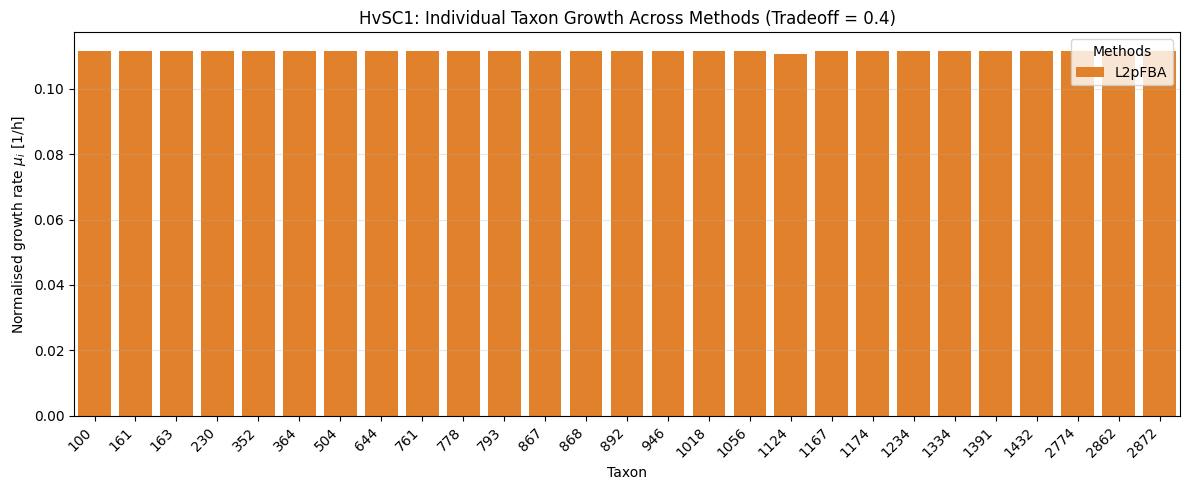

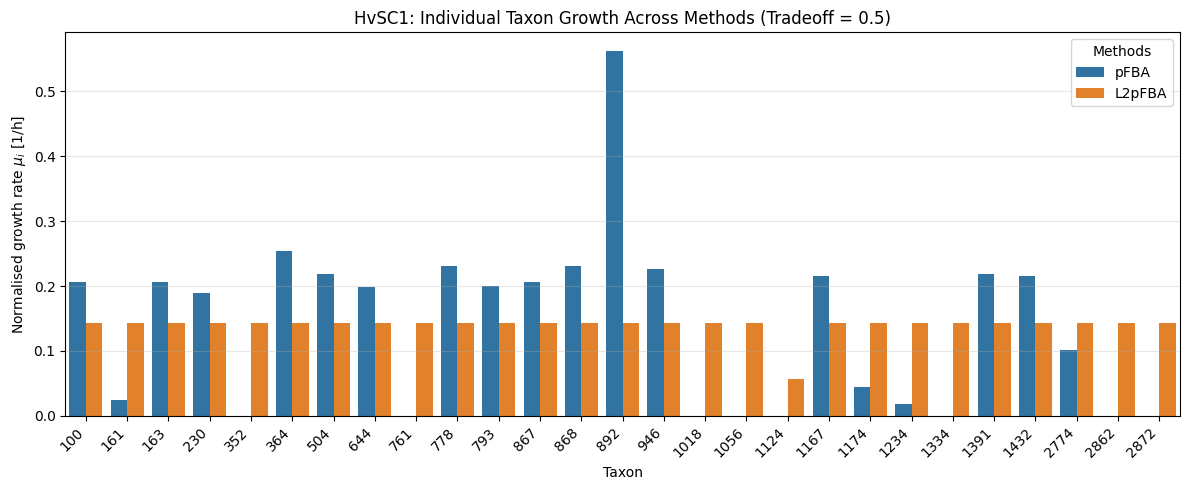

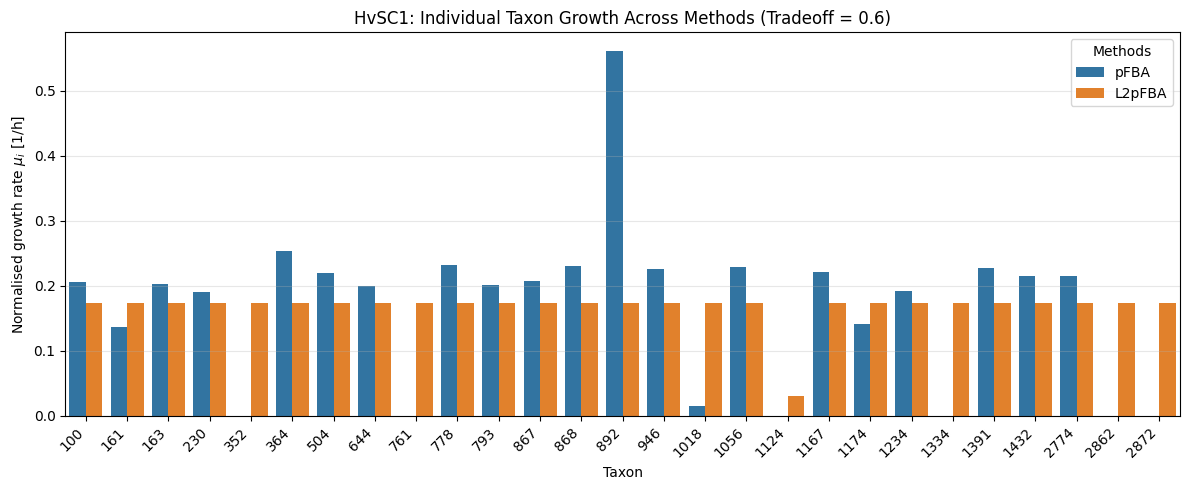

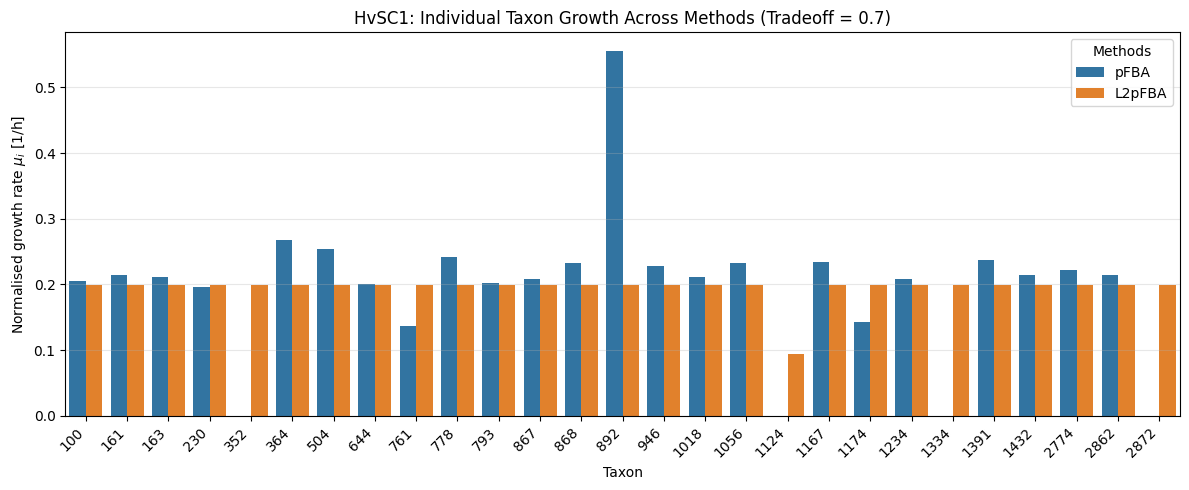

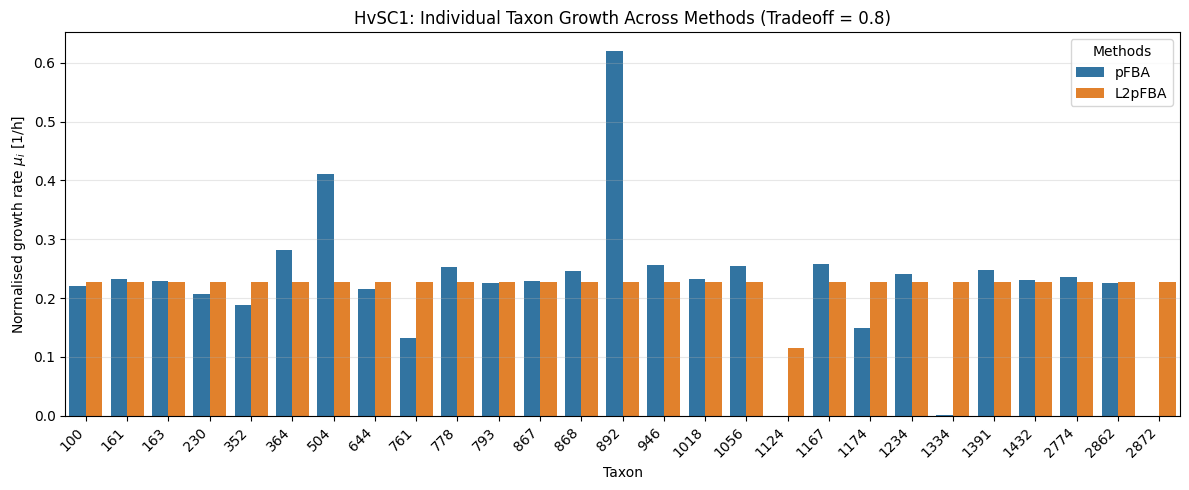

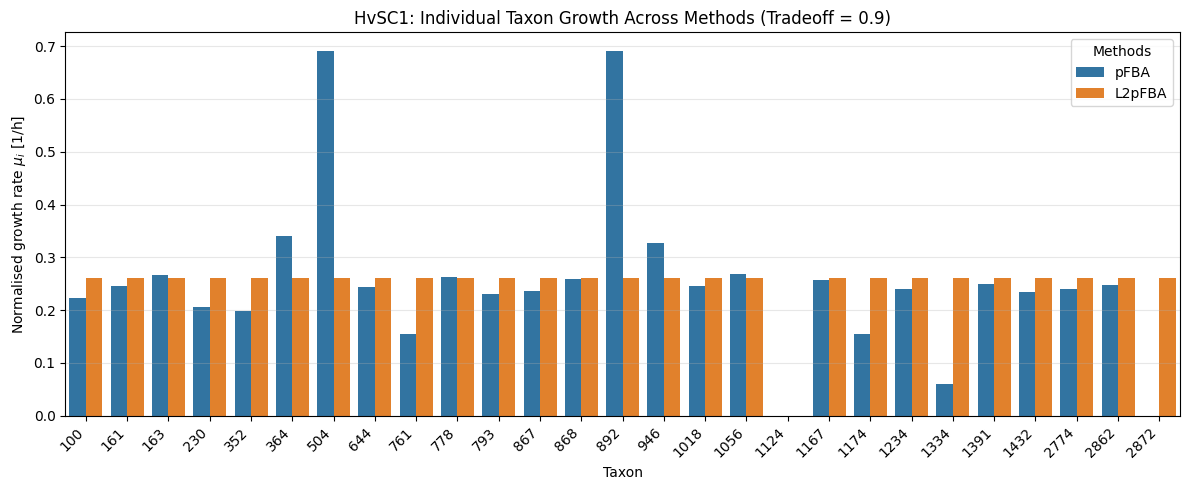

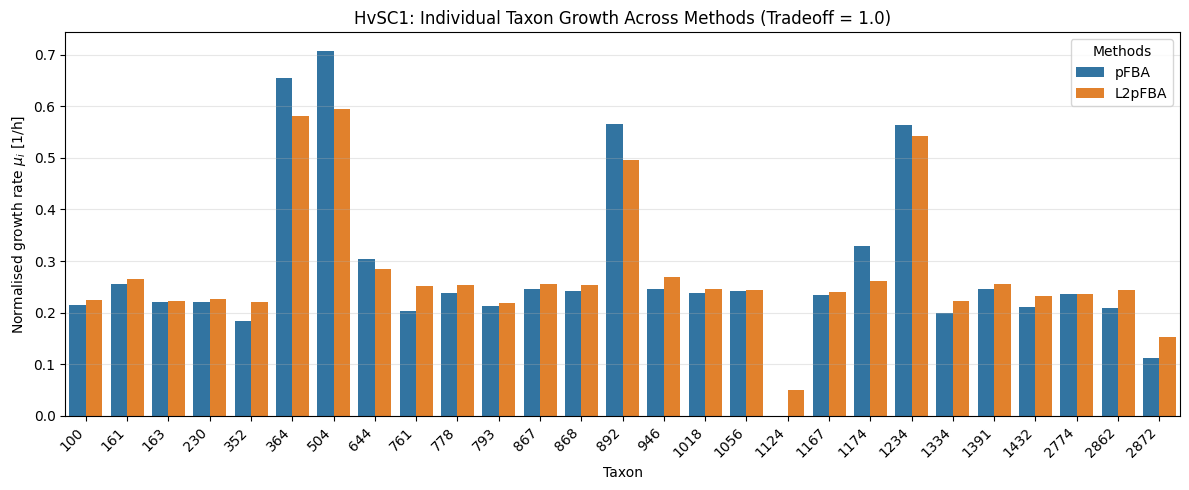

In [21]:
s_df = compare_growth_methods("HvSC1", save_dir, ["pfba", "l2pfba"])

## 5. first run L2, then add pFBA 

#### 5.1 get results

In [37]:
fractions = [x / 10.0 for x in range(0, 11, 1)]

In [38]:
l2pfba_sc1 = run_l2_then_pfba(HvSC1, fractions, fluxes=True)

optimal solution: 7.535269930920041
---------
Tradeoff-value: 0.0
Community objective: 0.0018195374169704447
pFBA solution (total flux): 26.55663608856344
---------
---------
Tradeoff-value: 0.1
Community objective: 0.7533516464342631
pFBA solution (total flux): 11320.867442893865
---------
---------
Tradeoff-value: 0.2
Community objective: 1.5068033056267764
pFBA solution (total flux): 22972.31436081637
---------
---------
Tradeoff-value: 0.3
Community objective: 2.260254921179727
pFBA solution (total flux): 34650.67689735347
---------
---------
Tradeoff-value: 0.4
Community objective: 3.013706561582847
pFBA solution (total flux): 46340.10670499214
---------
---------
Tradeoff-value: 0.5
Community objective: 3.76715820200385
pFBA solution (total flux): 58182.44974563849
---------
---------
Tradeoff-value: 0.6
Community objective: 4.520609842406481
pFBA solution (total flux): 70157.92393559354
---------
---------
Tradeoff-value: 0.7
Community objective: 5.274061482799194
pFBA solution 

In [39]:
l2pfba_sc2 = run_l2_then_pfba(HvSC2, fractions, fluxes=True)

optimal solution: 5.946647960973573
---------
Tradeoff-value: 0.0
Community objective: 0.006904797982938325
pFBA solution (total flux): 135.4820481708268
---------
---------
Tradeoff-value: 0.1
Community objective: 0.5945053327993571
pFBA solution (total flux): 10991.568310288761
---------
---------
Tradeoff-value: 0.2
Community objective: 1.1891106592408796
pFBA solution (total flux): 22151.30306803377
---------
---------
Tradeoff-value: 0.3
Community objective: 1.7837159888534326
pFBA solution (total flux): 33356.3445844294
---------
---------
Tradeoff-value: 0.4
Community objective: 2.378321318493596
pFBA solution (total flux): 44501.84055579139
---------
---------
Tradeoff-value: 0.5
Community objective: 2.972926648208217
pFBA solution (total flux): 56729.51456541549
---------
---------
Tradeoff-value: 0.6
Community objective: 3.567531977773939
pFBA solution (total flux): 70398.13663395151
---------
---------
Tradeoff-value: 0.7
Community objective: 4.162137307334076
pFBA solution 

In [32]:
l2pfba_sc2_892 = run_l2_then_pfba(HvSC2_892, fractions, fluxes=True)

optimal solution: 6.437879505911612
---------
Tradeoff-value: 0.5
Community objective: 3.2185178589825814
pFBA solution (total flux): 63222.12450084608
---------
---------
Tradeoff-value: 1
Community objective: 6.437135719296653
pFBA solution (total flux): 233076.48571240954
---------


In [34]:
save_tradeoff_results(l2pfba_sc2_892, "/home/emma/Dokumente/thesis/communities/simulations/pfba",prefix="HvSC2_892_l2pfba")

Results successfully saved to: /home/emma/Dokumente/thesis/communities/simulations/pfba


In [45]:
save_tradeoff_results(l2pfba_sc1, "/home/emma/Dokumente/thesis/communities/simulations/pfba",prefix="HvSC1_l2pfba")

Results successfully saved to: /home/emma/Dokumente/thesis/communities/simulations/pfba


In [46]:
save_tradeoff_results(l2pfba_sc2, "/home/emma/Dokumente/thesis/communities/simulations/pfba",prefix="HvSC2_l2pfba")

Results successfully saved to: /home/emma/Dokumente/thesis/communities/simulations/pfba


#### 5.2 compare this to pfba and L2 only 

In [47]:
method_list = ["pfba", "L2", "l2pfba"]

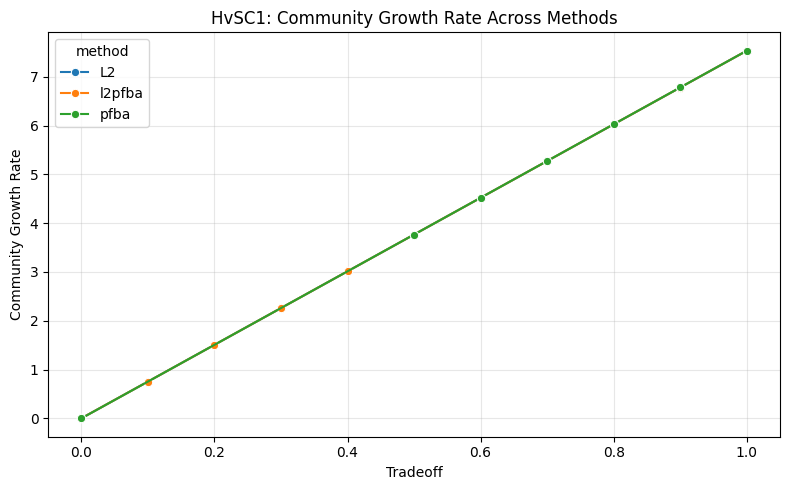

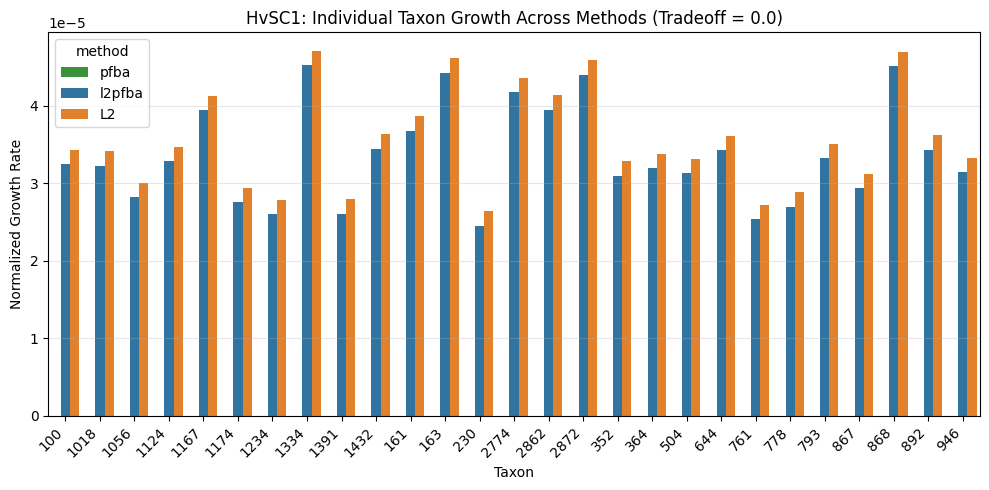

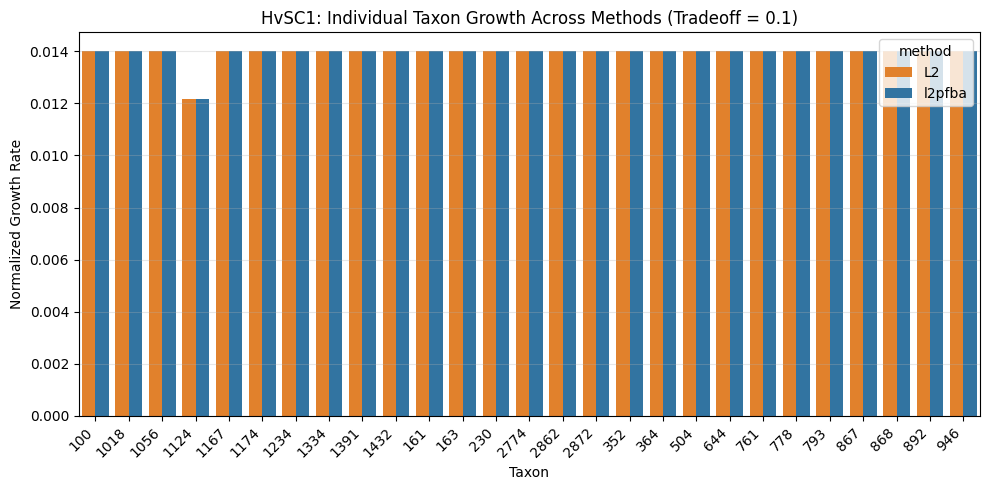

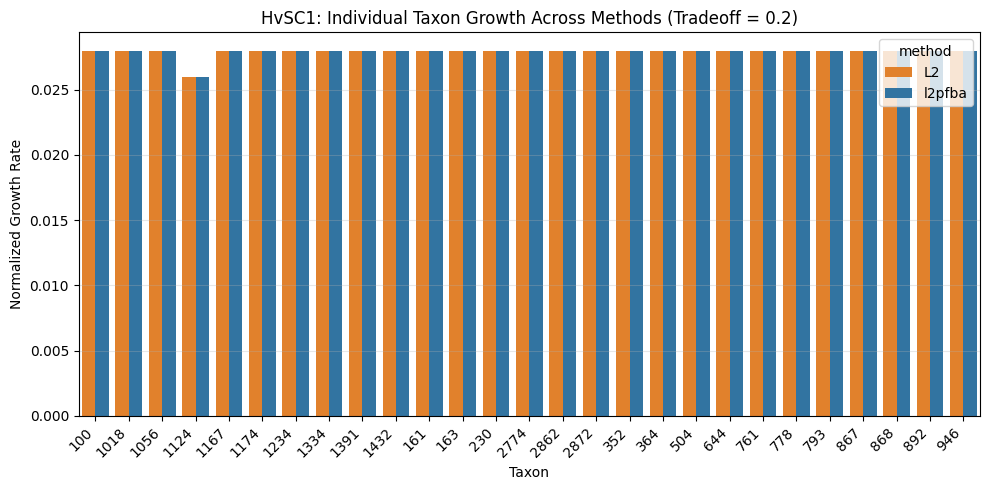

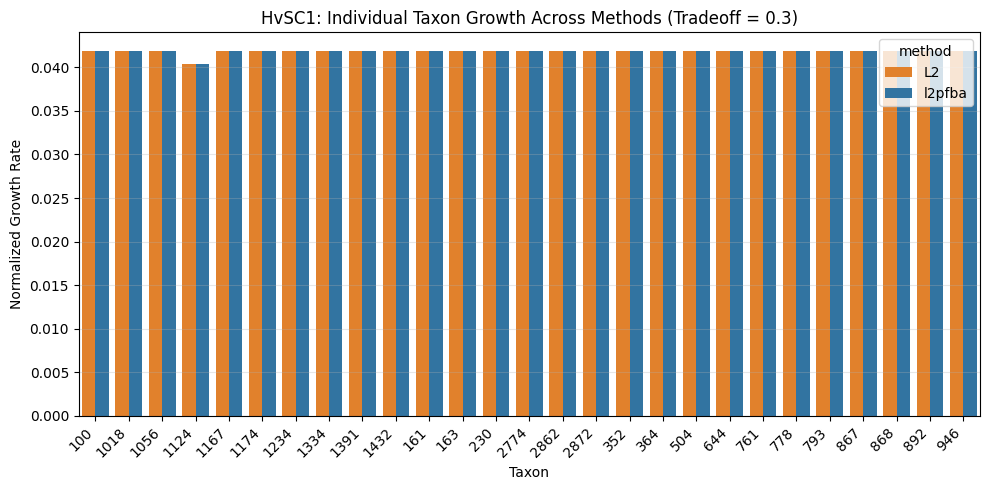

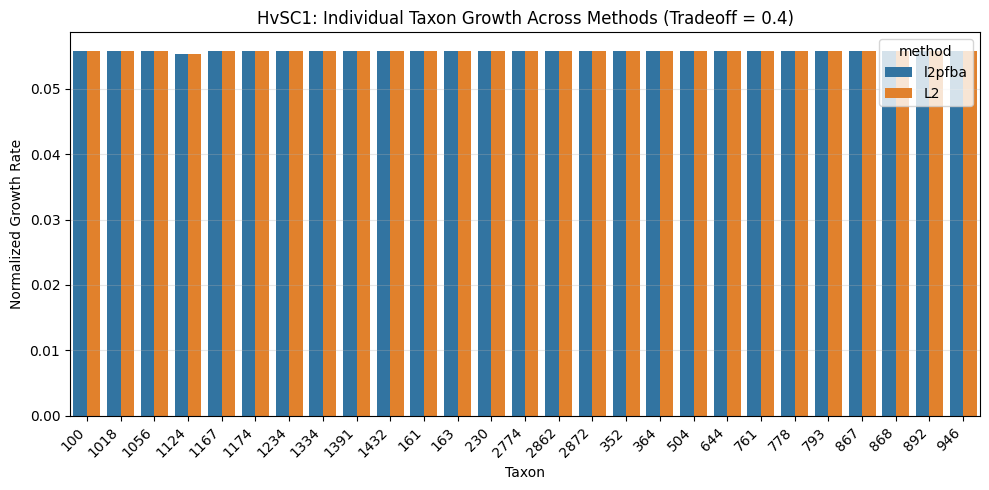

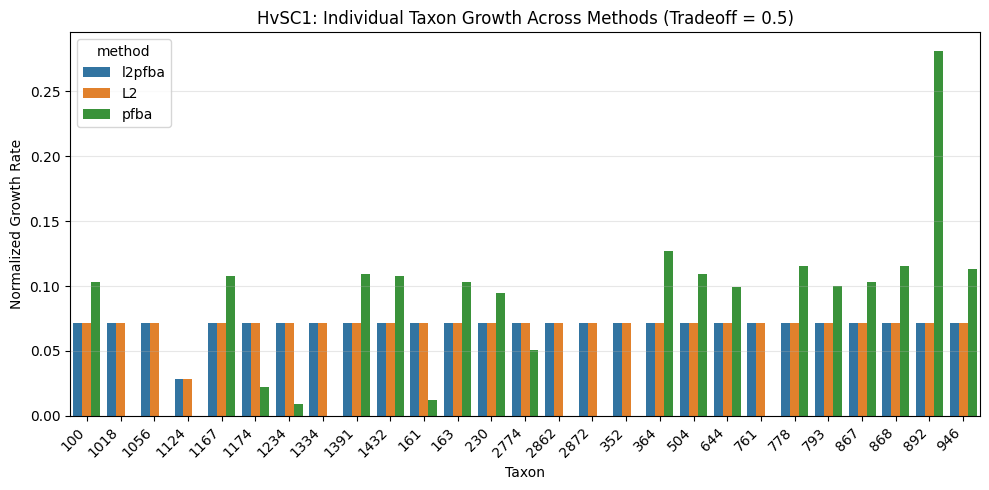

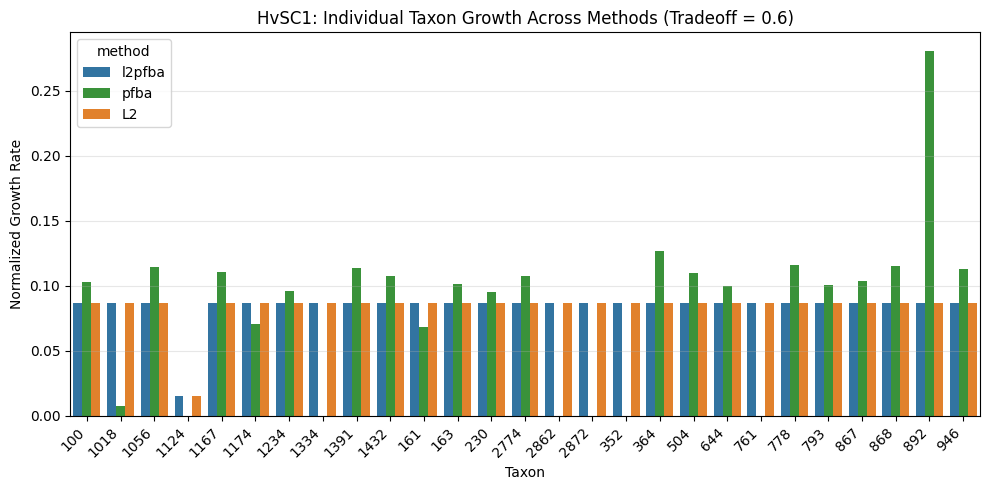

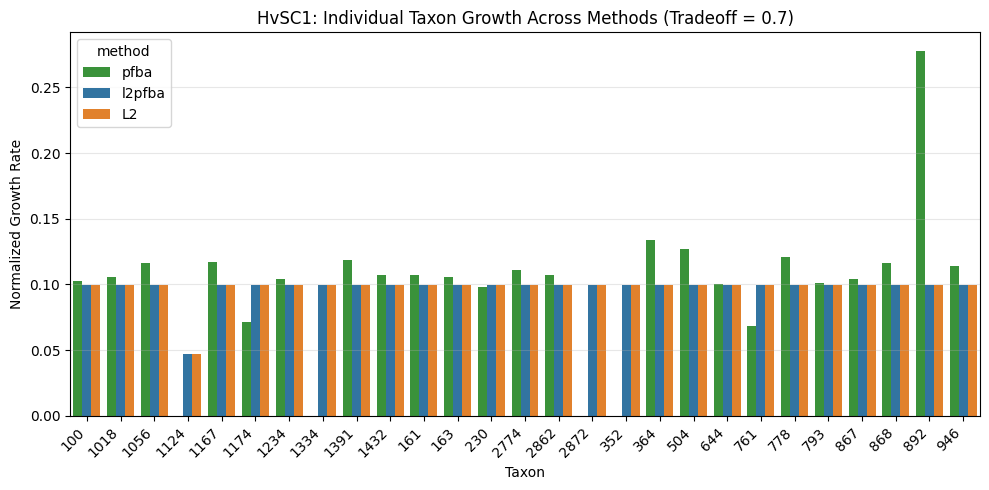

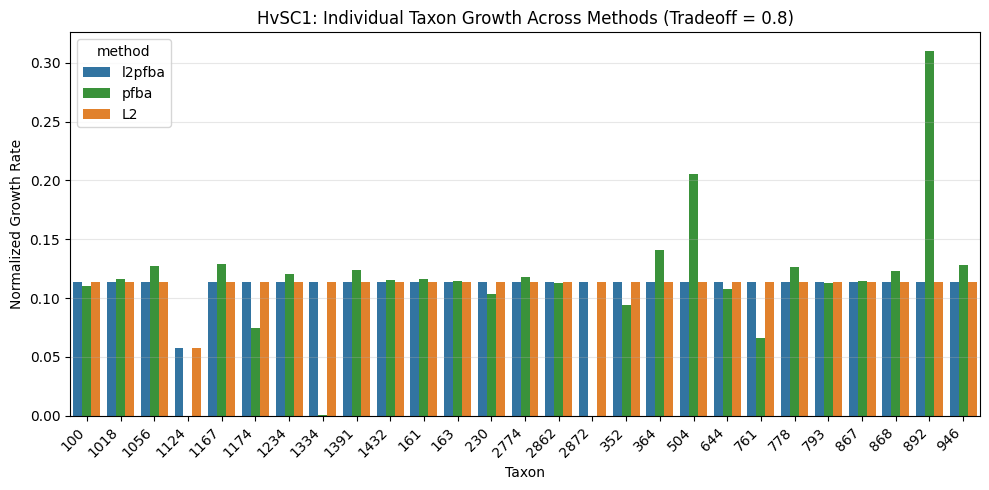

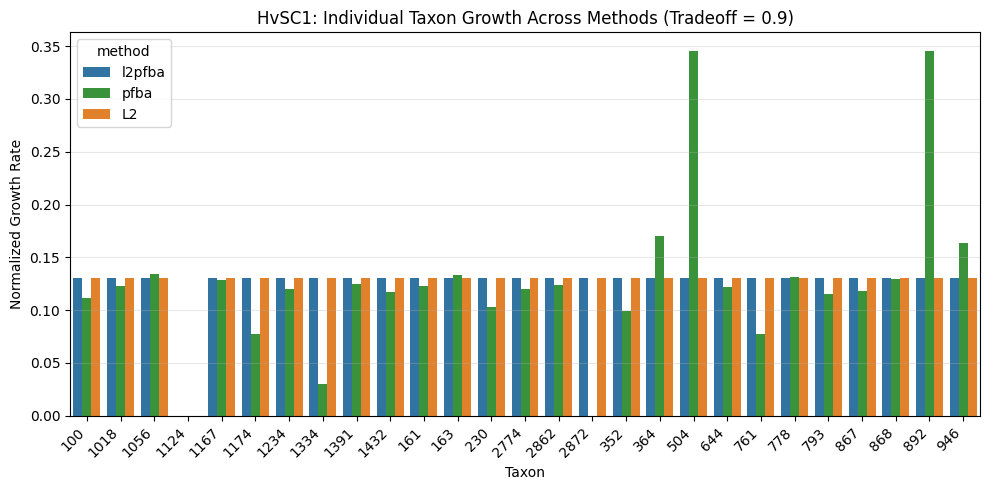

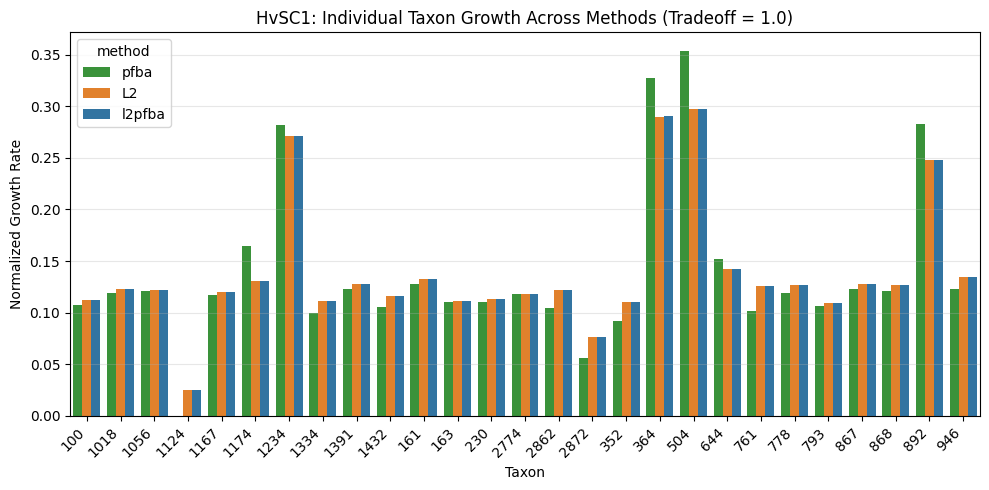

(    tradeoff  community_growth  objective_value   status  method
 0        0.0          0.001920    -1.025607e-01  numeric      L2
 1        0.0          0.001820     2.655664e+01  numeric  l2pfba
 2        0.0          0.000000     0.000000e+00  optimal    pfba
 3        0.1          0.753352    -1.533335e+04  numeric      L2
 4        0.1          0.753352     1.132087e+04  numeric  l2pfba
 5        0.2          1.506803    -6.131349e+04  numeric      L2
 6        0.2          1.506803     2.297231e+04  numeric  l2pfba
 7        0.3          2.260255    -1.379430e+05  numeric      L2
 8        0.3          2.260255     3.465068e+04  optimal  l2pfba
 9        0.4          3.013707    -2.452264e+05  numeric      L2
 10       0.4          3.013707     4.634011e+04  optimal  l2pfba
 11       0.5          3.767158    -3.883239e+05  numeric      L2
 12       0.5          3.767158     5.818245e+04  optimal  l2pfba
 13       0.5          3.767630     5.143718e+04  optimal    pfba
 14       

In [50]:
compare_growth_methods("HvSC1", save_dir, method_list)

In [ ]:
save_tradeoff_results(results_sc1, "/home/emma/Dokumente/thesis/communities/simulations/pfba",prefix="HvSC1_pfba_x")

Results successfully saved to: /home/emma/Dokumente/thesis/communities/simulations/pfba


In [ ]:
save_tradeoff_results(results_sc2, "/home/emma/Dokumente/thesis/communities/simulations/pfba",prefix="HvSC2_pfba_x")

Results successfully saved to: /home/emma/Dokumente/thesis/communities/simulations/pfba


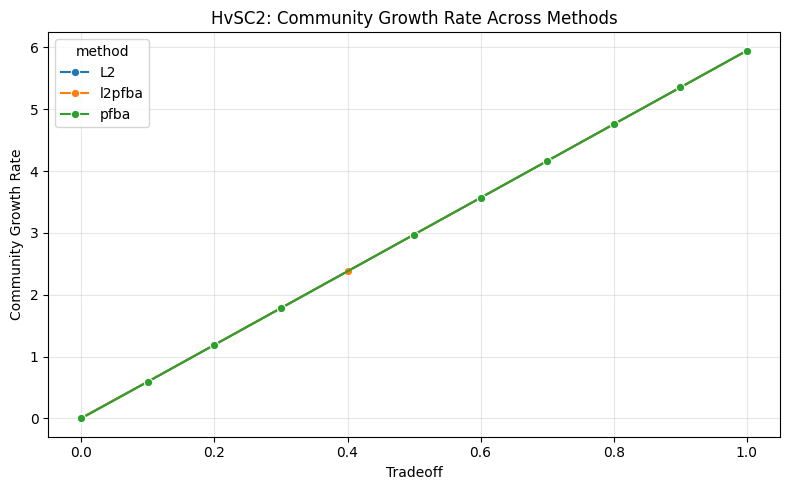

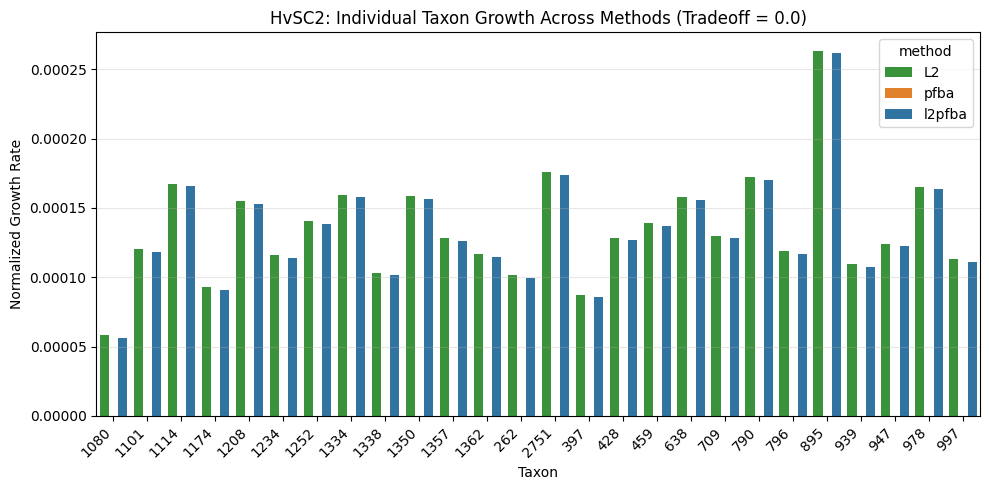

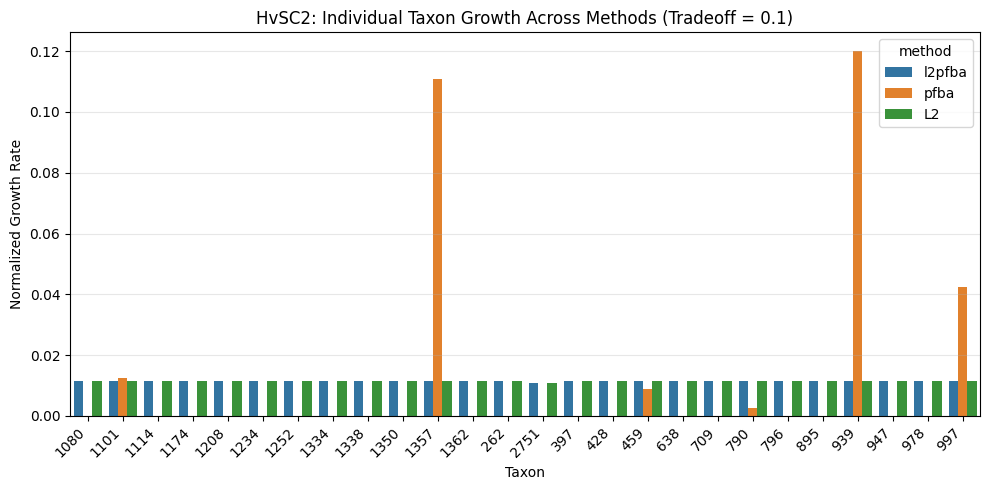

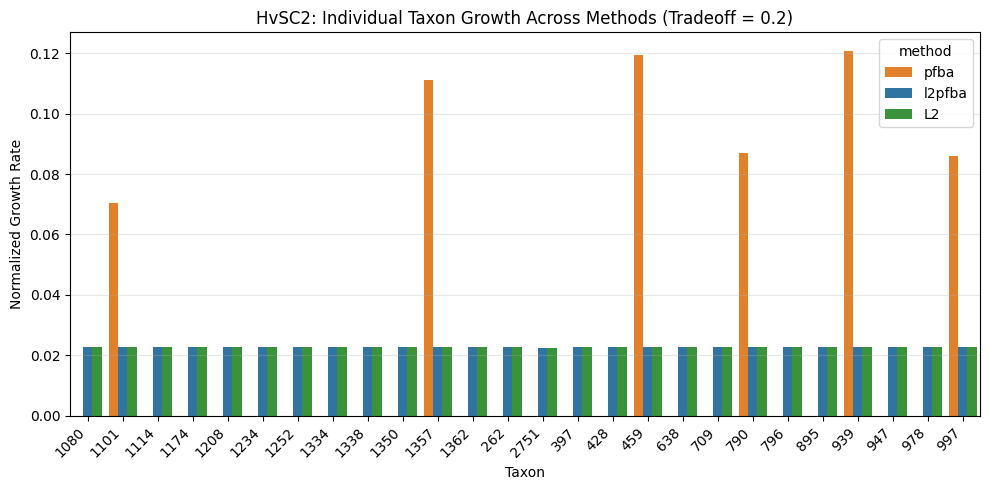

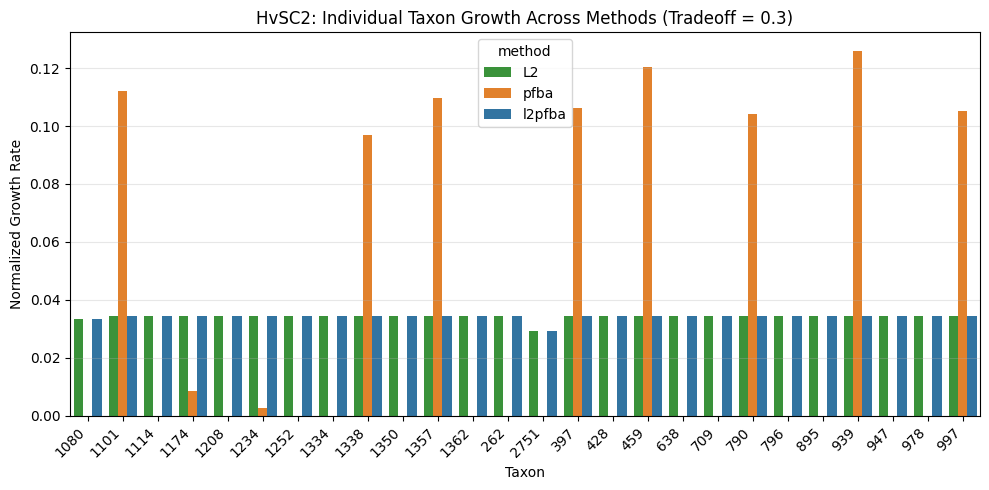

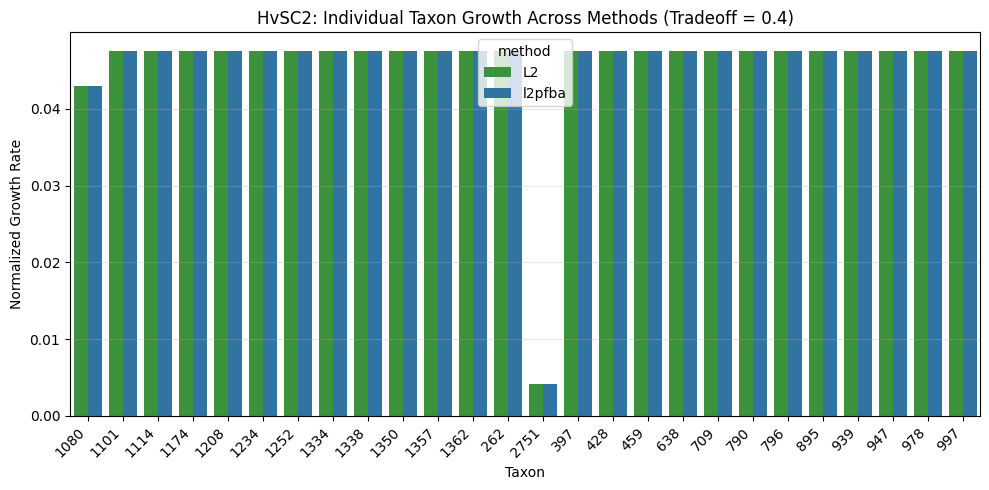

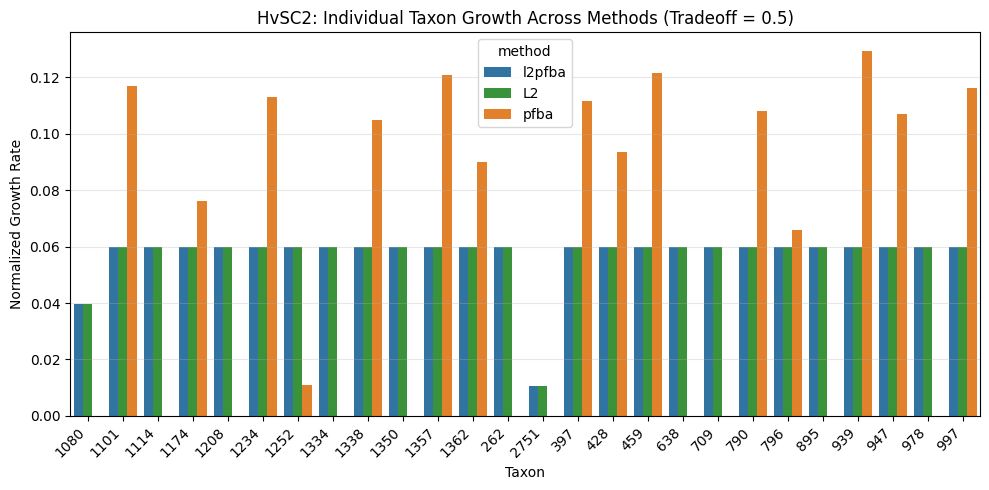

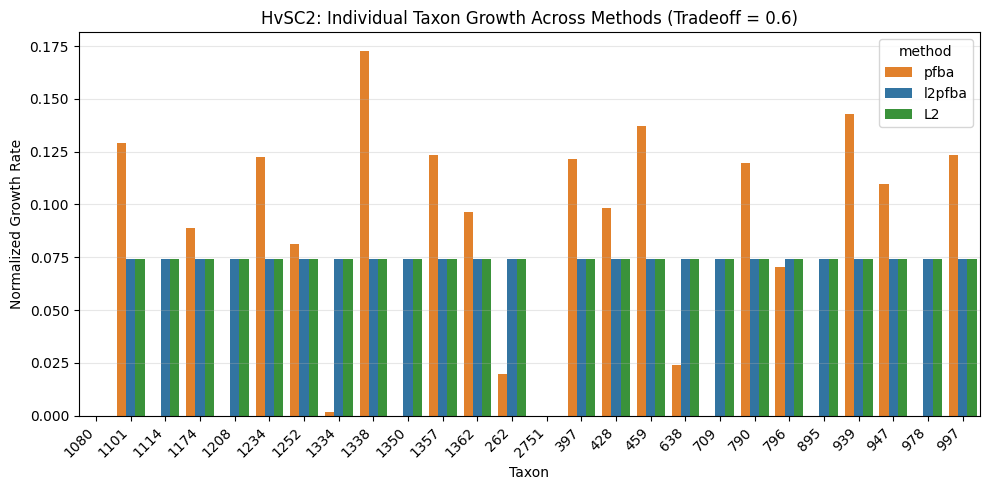

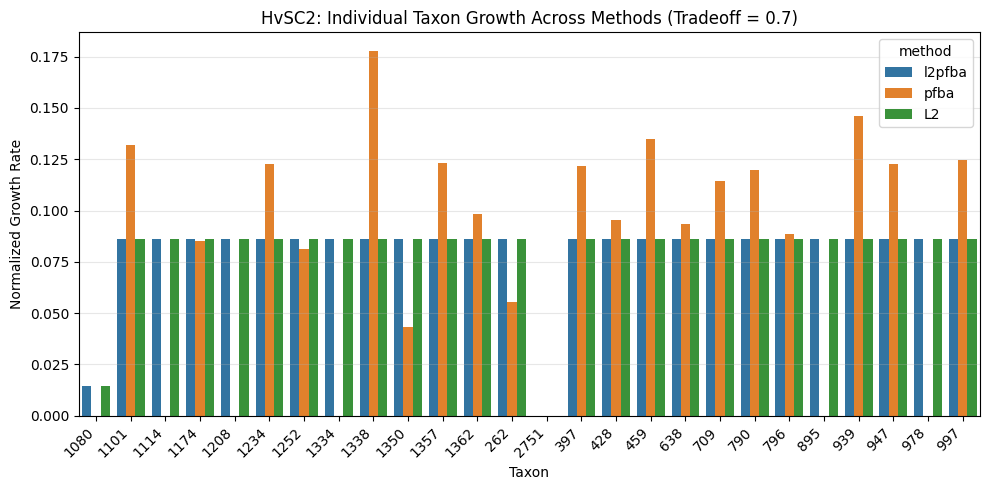

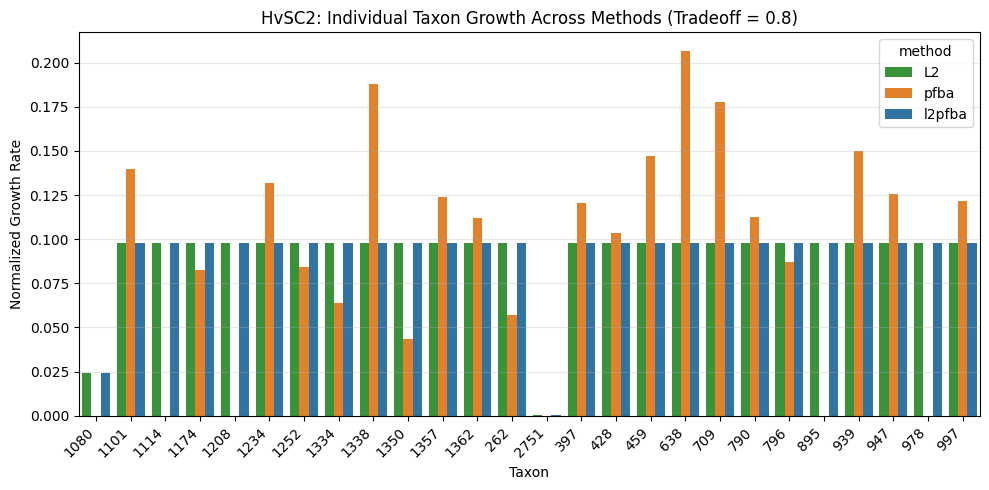

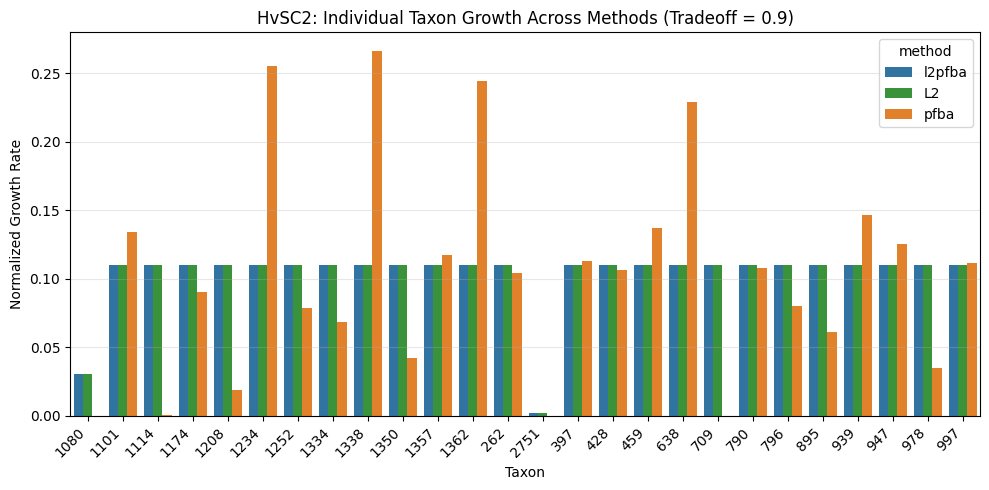

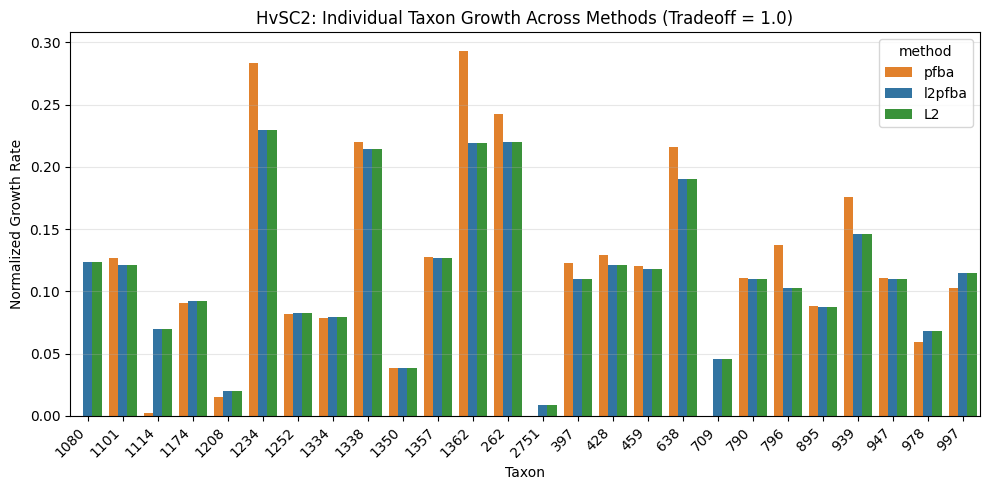

(    tradeoff  community_growth  objective_value   status  method
 0        0.0          0.007005    -1.379450e+00  numeric      L2
 1        0.0          0.006905     1.354820e+02  numeric  l2pfba
 2        0.0          0.000000     0.000000e+00  optimal    pfba
 3        0.1          0.594505    -9.190141e+03  numeric      L2
 4        0.1          0.594505     1.099157e+04  numeric  l2pfba
 5        0.1          0.594609     7.087883e+03  optimal    pfba
 6        0.2          1.189111    -3.676401e+04  numeric      L2
 7        0.2          1.189111     2.215130e+04  optimal  l2pfba
 8        0.2          1.189220     1.443897e+04  optimal    pfba
 9        0.3          1.783716    -8.279184e+04  numeric      L2
 10       0.3          1.783716     3.335634e+04  optimal  l2pfba
 11       0.3          1.783830     2.232217e+04  optimal    pfba
 12       0.4          2.378321    -1.519958e+05  numeric      L2
 13       0.4          2.378321     4.450184e+04  optimal  l2pfba
 14       

In [49]:
compare_growth_methods("HvSC2", save_dir, method_list)